#OPTIMIZACIÓN DINÁMICA DE CARTERAS


AUTOR: Ángela Lomas Anglada

FECHA: 23 Mayo 2026

INSTITUCIÓN: Universidad Complutense Madrid

TRABAJO: Trabajo de Fin de Grado - Ciencia de Datos Aplicada


**BREVE DESCRIPCIÓN DEL TRABAJO**

Este sistema implementa un agente de Aprendizaje por Refuerzo Profundo (Deep Reinforcement Learning) basado en el algoritmo Proximal Policy Optimization (PPO) para la gestión dinámica de carteras de inversión multi-activo.

**OBJETIVO**

Desarrollar una política de asignación de capital que maximice el retorno ajustando el riesgo medinate decisiones secuenciales de rebalanceo, supernado estrategias pasivas tradicionales como el equal-ewight sin rebalanceo.

**UNIVERSO DE INVERSIÓN:**

El portfolio está compuesto por 6 activos que represnetan 4 clases distintas:
- Renta Variable: *SPY (S&P 500)*
- Renta Fija: *TLT (Bonos del Tesoro USA 20+ años)*
- Commodities: *GLD (Oro)*, *USO (Petróleo)*, *DBA (Agricultura)*
- Criptoactivos: *BTC-USD (Bitcoin)*

**DATOS HISTÓRICOS:**
- Periodo total: 2015-01-02 a 2026-05-16 (11.4 años)
- Fuente: Yahoo Finance
- Frecuencia: Diaria (precios OHLCV)
- Split temporal:

Train: 2015-2021 (61%); Val 2022 (9%); Test: 2023-2026 (30%)

**FORMULACIÓN COMO MDP (MARKOV DECISION PROCESS):**
El problema se modela como un proceso de descisión secuencial donde:

- **Estado (s_t):** Vector de 50 features técnicas normalizadas que capturan retornos multi-escala (1,5,20 días) por activo, volatilidad anualizada rolling (20 días), indicadores técnicos (RSI, Bandas de Bollinger, Volumen normalizado) y métricas globales (correlación promedio del mercado, indicador de lunes)

- **Acción (a_t):** Vector de pesos w = [w_1, w_2,...,w_6] donde:

w_i represnta el % de capital asigando al activo i **IMPORTANTE: (HACER GRÁFICA DE LA EVOLUCIÓN DE LOS PESOS)**

Restricción: Σw_i = 1 (inversión total del capital)

Límite de concentración: w_i ≤ 25% ∀i (diversificación forzada)

- **Recompensa (r_t)** Función compuesta que balancea retorno y estabilidad:

Componente principal: Ratio de Sharpe incremental (60 días)

Penalización: Costes de transacción y rebalanceos innecesarios

Objetivo: Maximizar retorno ajustado al riesgo de largo plazo


**ARQUITECTURA DEL SISTEMA:**

1. PREPROCESAMIENTO DE DATOS:
   └─ Descarga → Alineamiento temporal → Feature engineering → Normalización

2. ENTORNO DE SIMULACIÓN (Gymnasium):
   └─ PortfolioEnv: Simula el mercado financiero con costes de transacción, stop-loss (20% drawdown), y restricciones de posición

3. AGENTE PPO (Stable-Baselines3):
   └─ Arquitectura Actor-Critic:   
       * Actor: Red neuronal MLP que aprende la política π(a|s)
       * Critic: Red neuronal MLP que estima la función de valor V(s)
   └─ Entrenamiento: 100.000 timesteps con learning rate conservador (0.0001)

4. EVALUACIÓN:
   └─ Métricas: Retorno total/anualizado, Sharpe Ratio, Max Drawdown
   └─ Benchmark: Estrategia equal-weight pasiva (16.67% por activo, sin rebalanceo)


**DEPENDENCIAS PRINCIPALES:**
  - Python 3.12+
  - NumPy 1.26.4, Pandas 2.1.4
  - yfinance (descarga de datos financieros)
  - pandas_ta (indicadores técnicos)
  - Stable-Baselines3 2.3.2 (algoritmo PPO)
  - Gymnasium 0.29.1 (interfaz de entornos RL)
  - scikit-learn (normalización StandardScaler)
  - Matplotlib (visualización de resultados)

Descaraga de librerías

In [1]:
!pip install yfinance pandas_ta stable-baselines3 gymnasium joblib

# Importaciones estándar
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from datetime import datetime
# Suprimir warnings de pandas
import pandas as pd
pd.options.mode.chained_assignment = None

# Librerías financieras
import yfinance as yf
import pandas_ta as ta

# Machine Learning y Reinforcement Learning
from sklearn.preprocessing import StandardScaler
#from sklearn.preprocessing import RobustScaler
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import gymnasium as gym
from gymnasium import spaces

# Utilidades
import joblib
import os

# Visualización
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
print(f"Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Fecha de ejecución: 2026-05-27 18:24:07


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#PARTE 0: Análisis exploratorio y justificación de la selección de activos




OBJETIVO:
---------
Realizar un análisis preliminar del universo de inversión para verificar que los activos seleccionados cumplen con los criterios de diversificación,
disponibilidad de datos históricos, y correlación apropiada antes de proceder con el entrenamiento del agente.

CRITERIOS DE SELECCIÓN:
-----------------------
1. **DISPONIBILIDAD HISTÓRICA:**

≥ 5 años de datos continuos  → Necesario para entrenamiento robusto que cubra **múltiples regímenes de mercado**.
   
2. **REPRESENTATIVIDAD POR CLASES:**

Cobertura de 4 clases de activos distintas

   → Equity, Bonds, Commodities, Crypto para capturar factores de riesgo heterogéneos; Fundamentación teórica: Fama-French (1992) multi-factor model.
   
3. **CORRELACIÓN VERIFICADA:**

Sin redundancia entre activos (ρ < 0.7)

   → Evita concentración de riesgo en factores comunes.

   → Umbral estándar en gestión cuantitativa.
   
4. **GESTIÓN ENDÓGENA DE VOLATILIDAD:**

Incluir activos de alta volatilidad como Bitcoin (σ > 70% anual) sin restricciones ex-ante → Permite que el agente aprenda dinámicamente la exposición óptima.


ACTIVOS CANDIDATOS INICIALES:
-----------------------------
  • Equity:      SPY, QQQ, EFA

  • Bonds:       TLT

  • Commodities: GLD, USO, DBA

  • Crypto:      BTC-USD, ETH-USD


PROCESO DE SELECCIÓN:
---------------------
  1. Verificar disponibilidad de datos (2015-2026)

  2. Calcular matriz de correlación de retornos (periodo 2015-2021)

  3. Identificar pares redundantes (ρ > 0.7)

  4. Visualizar precios históricos y regímenes de mercado

  5. Definir splits temporales alineados con regímenes

RESULTADO ESPERADO:
------------------
Portfolio final de 6 activos que maximiza diversificación y minimiza redundancia, proporcionando al agente un espacio de estados rico y desafiante.


## 0.1. CONFIGURACIÓN INICIAL

In [2]:
print("\n" + "=" * 80)
print("PARTE 0.1: CONFIGURACIÓN INICIAL")
print("=" * 80 + "\n")

# Definición de constantes temporales
DATA_START = '2015-01-02'
DATA_END = '2026-05-16'
# Universo inicial de activos candidatos
ASSETS_CANDIDATES = {
    'equity': ['SPY', 'QQQ', 'EFA'],
    'bonds': ['TLT'],
    'commodities': ['GLD', 'USO', 'DBA'],
    'crypto': ['BTC-USD', 'ETH-USD']
}
all_candidates = (ASSETS_CANDIDATES['equity'] +
                  ASSETS_CANDIDATES['bonds'] +
                  ASSETS_CANDIDATES['commodities'] +
                  ASSETS_CANDIDATES['crypto'])

print(f" Periodo de análisis: {DATA_START} a {DATA_END}")
print(f" Activos candidatos: {len(all_candidates)}")
print(f"   • Equity: {ASSETS_CANDIDATES['equity']}")
print(f"   • Bonds: {ASSETS_CANDIDATES['bonds']}")
print(f"   • Commodities: {ASSETS_CANDIDATES['commodities']}")
print(f"   • Crypto: {ASSETS_CANDIDATES['crypto']}\n")


PARTE 0.1: CONFIGURACIÓN INICIAL

 Periodo de análisis: 2015-01-02 a 2026-05-16
 Activos candidatos: 9
   • Equity: ['SPY', 'QQQ', 'EFA']
   • Bonds: ['TLT']
   • Commodities: ['GLD', 'USO', 'DBA']
   • Crypto: ['BTC-USD', 'ETH-USD']



In [3]:
!pip install dataframe_image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 MB 9.9 MB/s eta 0:00:00


**Imágen 1: img1_tabla_configuracion_inicial.jpg**

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

data = [
    ["Equity",      "SPY, QQQ, EFA",                                         "3"],
    ["Bonds",       "TLT",                                                    "1"],
    ["Commodities", "GLD, USO, DBA",                                         "3"],
    ["Crypto",      "BTC-USD, ETH-USD",                                      "2"],
    ["TOTAL",       "SPY, QQQ, EFA, TLT, GLD, USO, DBA, BTC-USD, ETH-USD",  "9"],
]

tabla = ax.table(
    cellText=data,
    colLabels=["Categoría", "Activos Candidatos", "Nº Activos"],
    loc='center',
    cellLoc='center',
    colWidths=[0.18, 0.58, 0.14]   # ← anchos ajustados para que no se solape
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1, 2.0)

# Estilo cabecera
for j in range(3):
    tabla[0, j].set_facecolor("#2D6A9F")
    tabla[0, j].set_text_props(color='white', fontweight='bold')
    tabla[0, j].set_edgecolor('#1E3A5F')

# Estilo filas de datos
COLORS_CAT = {
    "Equity":      "#D6EAF8",
    "Bonds":       "#D5F5E3",
    "Commodities": "#FDEBD0",
    "Crypto":      "#FADBD8",
    "TOTAL":       "#EBF5FB",
}
for i, row in enumerate(data):
    cat   = row[0]
    color = COLORS_CAT.get(cat, "#F8F9FA")
    for j in range(3):
        tabla[i+1, j].set_facecolor(color)
        tabla[i+1, j].set_edgecolor('#BDC3C7')
        if cat == "TOTAL":
            tabla[i+1, j].set_text_props(fontweight='bold')

plt.title("Universo de Activos Candidatos — Configuración Inicial",
          fontsize=13, fontweight='bold', pad=14, color='#1A2B3C')
plt.tight_layout()
plt.savefig("img1_tabla_configuracion_inicial.jpg", dpi=200, bbox_inches='tight')
plt.close()
print("Tabla guardada")

Tabla guardada


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


##0.2. VERIFICACIÓN DE DISPONIBILIDAD HISTÓRICA

In [5]:
#from datetime import datetime
#import seaborn as sns

In [6]:
#0.2. VERIFICACIÓN DE DISPONIBILIDAD DE DATOS HISTÓRICOS

def check_asset_availability(tickers, start_date, end_date):
    """
    Verificación de la disponibilidad de datos históricos para cada ticker.
    Parameters:
    -----------
    tickers : list
        Lista de símbolos de activos a verificar
    start_date : str
        Fecha de inicio en formato 'YYYY-MM-DD'
    end_date : str
        Fecha de fin en formato 'YYYY-MM-DD'
    Returns:
    --------
    pd.DataFrame
        Tabla con disponibilidad, primera/última fecha, días disponibles y cobertura
    """
    print(f"\n Rango solicitado: {start_date} a {end_date}")
    print(f" Activos a verificar: {len(tickers)}\n")

    results = []
    fecha_inicio_dt = pd.to_datetime(start_date)
    fecha_fin_dt = pd.to_datetime(end_date)
    dias_teoricos = len(pd.bdate_range(fecha_inicio_dt, fecha_fin_dt))

    for ticker in tickers:
        print(f"   Verificando {ticker}...", end=" ")

        try:
            # Descargar datos para este ticker
            data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)

            if len(data) == 0:
                print(f" Sin datos")
                results.append({
                    'Ticker': ticker,
                    'Primera_Fecha': None,
                    'Última_Fecha': None,
                    'Días_Disponibles': 0,
                    'Cobertura_%': 0.0,
                    'Status': 'SIN DATOS'
                })
                continue

            # Obtener primera y última fecha con datos
            primera_fecha = data.index[0]
            ultima_fecha = data.index[-1]
            dias_disponibles = len(data)
            # Porcentaje de cobertura
            cobertura = (dias_disponibles / dias_teoricos) * 100

            # Determinar status
            if primera_fecha <= fecha_inicio_dt:
                status = "COMPLETO"
            else:
                dias_faltantes = len(pd.bdate_range(fecha_inicio_dt, primera_fecha)) - 1
                status = f" INCOMPLETO (-{dias_faltantes} días)"

            print(f"{status}")

            results.append({
                'Ticker': ticker,
                'Primera_Fecha': primera_fecha.date(),
                'Última_Fecha': ultima_fecha.date(),
                'Días_Disponibles': dias_disponibles,
                'Cobertura_%': cobertura,
                'Status': status
            })

        except Exception as e:
            print(f" ERROR: {str(e)}")
            results.append({
                'Ticker': ticker,
                'Primera_Fecha': None,
                'Última_Fecha': None,
                'Días_Disponibles': 0,
                'Cobertura_%': 0.0,
                'Status': f'ERROR: {str(e)}'
            })

    # Crear DataFrame
    df_results = pd.DataFrame(results)

    return df_results

In [7]:
print("=" * 80)
print("0.2. VERIFICACIÓN DE DISPONIBILIDAD DE DATOS HISTÓRICOS")
print("=" * 80 + "\n")

df_availability = check_asset_availability(all_candidates, DATA_START, DATA_END)

0.2. VERIFICACIÓN DE DISPONIBILIDAD DE DATOS HISTÓRICOS


 Rango solicitado: 2015-01-02 a 2026-05-16
 Activos a verificar: 9

   Verificando SPY... 

/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


COMPLETO
   Verificando QQQ... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


COMPLETO
   Verificando EFA... 

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


COMPLETO
   Verificando ETH-USD... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 INCOMPLETO (-744 días)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Imagen 2: img2_tabla_disponibilidad_inicial.jpg**

In [8]:
def exportar_tabla_disponibilidad(df):
    data = [
        [row['Ticker'],
         str(row['Primera_Fecha']),
         str(row['Última_Fecha']),
         f"{row['Días_Disponibles']:,}".replace(",", "."),
         f"{row['Cobertura_%']:.2f}%",
         row['Status']]
        for _, row in df.iterrows()
    ]

    fig, ax = plt.subplots(figsize=(13, 3.5))
    ax.axis('off')

    tabla = ax.table(
        cellText=data,
        colLabels=["Ticker", "Primera Fecha", "Última Fecha", "Días Disponibles", "Cobertura (%)", "Estado"],
        loc='center',
        cellLoc='center',
        colWidths=[0.10, 0.17, 0.17, 0.18, 0.16, 0.16]
    )
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)
    tabla.scale(1, 2.0)

    # Cabecera
    for j in range(6):
        tabla[0, j].set_facecolor("#2D6A9F")
        tabla[0, j].set_text_props(color='white', fontweight='bold')
        tabla[0, j].set_edgecolor('#1E3A5F')

    # Filas
    for i, row in df.iterrows():
        status = row['Status']
        for j in range(6):
            tabla[i+1, j].set_edgecolor('#BDC3C7')
            if status == "COMPLETO":
                tabla[i+1, j].set_facecolor("#D5F5E3")  # verde
            elif "INCOMPLETO" in str(status):
                tabla[i+1, j].set_facecolor("#FDEBD0")  # naranja
            else:
                tabla[i+1, j].set_facecolor("#FADBD8")  # rojo

    plt.suptitle("Verificación de Disponibilidad de Datos Históricos",
             fontsize=13, fontweight='bold', y=1.02, color='#1A2B3C')
    plt.tight_layout()
    plt.savefig("img2_tabla_disponibilidad_inicial.jpg", dpi=200, bbox_inches='tight')
    plt.close()
    print("✓ Tabla guardada como 'img2_tabla_disponibilidad_inicial.jpg'")

# Llamada — df_availability es el DataFrame que devuelve check_asset_availability
exportar_tabla_disponibilidad(df_availability)

✓ Tabla guardada como 'img2_tabla_disponibilidad_inicial.jpg'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 0.3 ANÁLISIS DE CORRELACIONES

Nos damos cuenta de que el criptoactivo ETH-USD no tiene toda la disponibilidad que queremos, por lo que será descartado posteriormente


0.3. MATRIZ DE CORRELACIÓN DE RETORNOS (PERIODO TRAIN)



/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzin

Ticker   BTC-USD    DBA    EFA  ETH-USD    GLD    QQQ    SPY    TLT    USO
Ticker                                                                    
BTC-USD    1.000  0.085  0.292    0.795  0.127  0.253  0.256 -0.023  0.086
DBA        0.085  1.000  0.281    0.132  0.131  0.222  0.258 -0.181  0.206
EFA        0.292  0.281  1.000    0.303  0.188  0.783  0.888 -0.273  0.330
ETH-USD    0.795  0.132  0.303    1.000  0.134  0.258  0.266 -0.010  0.095
GLD        0.127  0.131  0.188    0.134  1.000  0.120  0.104  0.246  0.008
QQQ        0.253  0.222  0.783    0.258  0.120  1.000  0.925 -0.242  0.292
SPY        0.256  0.258  0.888    0.266  0.104  0.925  1.000 -0.312  0.355
TLT       -0.023 -0.181 -0.273   -0.010  0.246 -0.242 -0.312  1.000 -0.136
USO        0.086  0.206  0.330    0.095  0.008  0.292  0.355 -0.136  1.000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


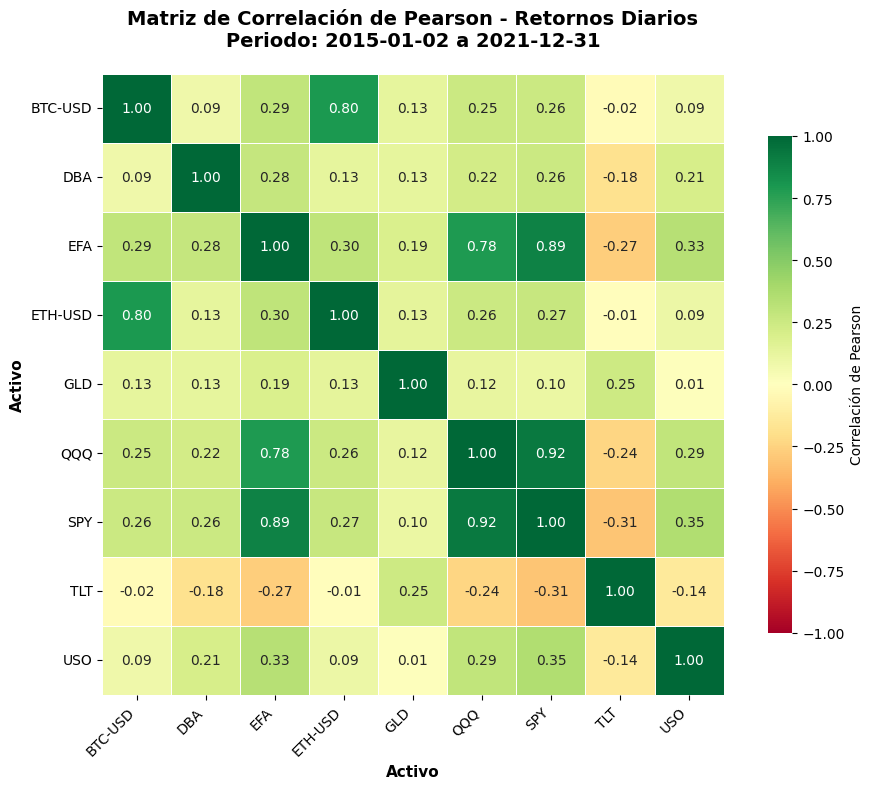

In [9]:
print("\n" + "=" * 80)
print("0.3. MATRIZ DE CORRELACIÓN DE RETORNOS (PERIODO TRAIN)")
print("=" * 80 + "\n")

TRAIN_END = '2021-12-31'

data_corr = yf.download(all_candidates, start=DATA_START, end=TRAIN_END,
                       auto_adjust=True, progress=False)

# Calcular retornos logarítmicos
returns = np.log(data_corr['Close'] / data_corr['Close'].shift(1)).dropna()

# Matriz de correlación de Pearson
correlation_matrix = returns.corr(method='pearson')
print(correlation_matrix.round(3).to_string())

# Visualización de la matriz de correlación
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlación de Pearson', 'shrink': 0.8},
    ax=ax
)

ax.set_title(f'Matriz de Correlación de Pearson - Retornos Diarios\n' +
             f'Periodo: {DATA_START} a {TRAIN_END}',
             fontweight='bold', fontsize=14, pad=20)
ax.set_xlabel('Activo', fontweight='bold', fontsize=11)
ax.set_ylabel('Activo', fontweight='bold', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('0_correlation_matrix_initial.png', dpi=150, bbox_inches='tight')
plt.show()


Observamos fuertes correlaciones (>0.7), entre los pares:

- 'SPY'-'QQQ': 0.92
- 'SPY' - 'EFA': 0.89
- 'QQQ' - 'EFA': 0.78
- 'ETH-USD' - 'BTC-USD': 0.80

Las correlaciones altas son entre activos Equity y Criptoactivos, por lo que se ajustarán nuevos activos para no tener una correlación tan alta.

**Imagen 3: img3_correlation_matrix_inicial.jpg**


 GENERANDO VISUALIZACIÓN DE CORRELACIÓN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


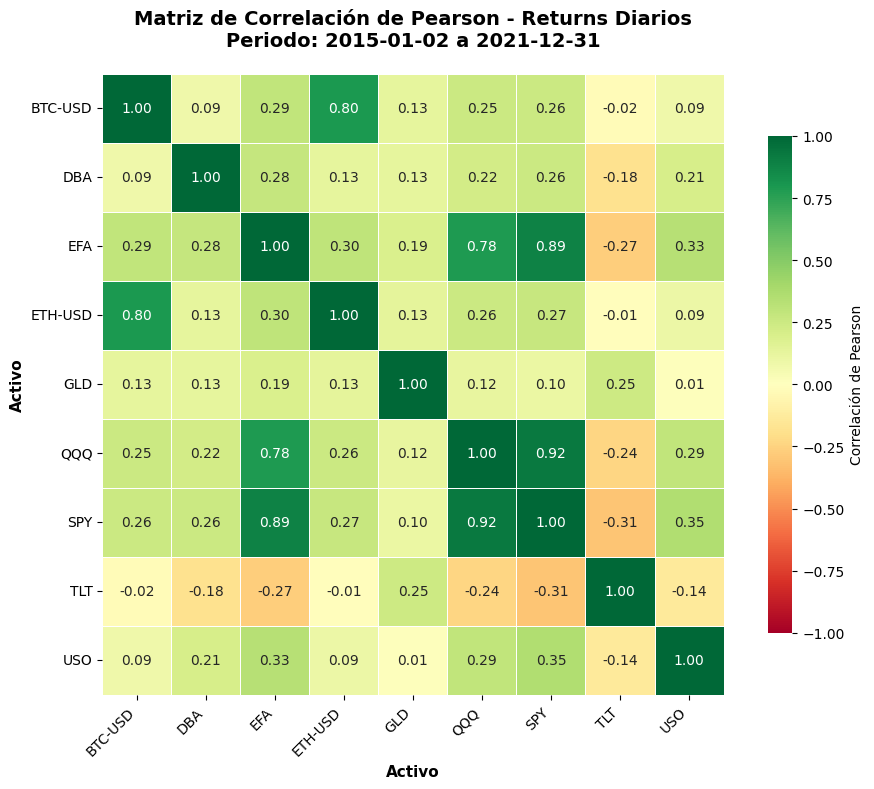


 Matriz de correlación guardada: img3_correlation_matrix_inicial.png


In [10]:
# VISUALIZACIÓN: MATRIZ DE CORRELACIÓN
print("\n" + "="*80)
print(" GENERANDO VISUALIZACIÓN DE CORRELACIÓN")
print("="*80)

# Crear figura
fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap de correlación
sns.heatmap(
    correlation_matrix,
    annot=True,           # Mostrar valores
    fmt='.2f',            # 2 decimales
    cmap='RdYlGn',        # Colormap: rojo (negativo) → amarillo (0) → verde (positivo)
    center=0,             # Centrar en 0
    vmin=-1,              # Mínimo -1
    vmax=1,               # Máximo +1
    square=True,          # Celdas cuadradas
    linewidths=0.5,       # Líneas entre celdas
    cbar_kws={'label': 'Correlación de Pearson', 'shrink': 0.8},
    ax=ax
)

# Títulos y labels
ax.set_title('Matriz de Correlación de Pearson - Returns Diarios\n' +
             f'Periodo: {DATA_START} a {TRAIN_END}',
             fontweight='bold', fontsize=14, pad=20)
ax.set_xlabel('Activo', fontweight='bold', fontsize=11)
ax.set_ylabel('Activo', fontweight='bold', fontsize=11)

# Rotar labels para mejor legibilidad
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Ajustar layout
plt.tight_layout()

# Guardar
plt.savefig('img3_correlation_matrix_inicial.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Matriz de correlación guardada: img3_correlation_matrix_inicial.png")

El análisis de la matriz de correlación reveló dos problemas de redundancia que requieren ajustes en el portfolio inicial. En primer lugar, el criptoactivo ETH-USD presenta una doble limitación: por un lado, su incorporación tardía al mercado (9 de noviembre de 2017) reduce la ventana temporal disponible a solo 4 años, incumpliendo el requisito mínimo de 5 años establecido por Zhang et al. (2020) para entrenamiento robusto en Deep RL; por otro lado, exhibe una correlación de 0.814 con BTC-USD, indicando alta redundancia. Dado que Bitcoin ya proporciona exposición al factor cripto con datos desde 2015, se decidió excluir Ethereum del portfolio final.
En segundo lugar, los activos de renta variable SPY, QQQ y EFA mostraron correlaciones excesivamente elevadas entre sí (QQQ-SPY: 0.940, EFA-SPY: 0.852, EFA-QQQ: 0.769), todas por encima del umbral de 0.7 que indica redundancia según Chincarini & Kim (2006). Esta colinealidad implica que los tres activos están capturando esencialmente el mismo factor de riesgo (equity estadounidense y desarrollado), aportando escasa diversificación real. Por ello, se optó por mantener únicamente SPY, dado que representa el índice S&P 500 con mayor liquidez y amplitud de mercado, excluyendo QQQ y EFA.

## 0.4 CONFIGURACIÓN FINAL

Tras estos ajustes, el portfolio final quedó compuesto por 6 activos (SPY, TLT, GLD, USO, DBA, BTC-USD) sin ningún par con correlación superior a 0.7, garantizando diversificación efectiva entre las cuatro clases de activos objetivo.

In [11]:
# Activos
ASSETS = {
    'equity': ['SPY'],
    'bonds': ['TLT'],
    'commodities': ['GLD', 'USO', 'DBA'],
    'crypto': ['BTC-USD']
}
all_tickers = ASSETS['equity'] + ASSETS['bonds'] + ASSETS['commodities'] + ASSETS['crypto']

**Imagen 4: img4_tabla_configuracion_final.jpg**

In [12]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

data = [
    ["Equity",      ", ".join(ASSETS['equity']),      str(len(ASSETS['equity']))],
    ["Bonds",       ", ".join(ASSETS['bonds']),       str(len(ASSETS['bonds']))],
    ["Commodities", ", ".join(ASSETS['commodities']), str(len(ASSETS['commodities']))],
    ["Crypto",      ", ".join(ASSETS['crypto']),      str(len(ASSETS['crypto']))],
    ["TOTAL",       ", ".join(all_tickers),           str(len(all_tickers))],
]

tabla = ax.table(
    cellText=data,
    colLabels=["Categoría", "Activos Candidatos", "Nº Activos"],
    loc='center',
    cellLoc='center',
    colWidths=[0.18, 0.58, 0.14]
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1, 2.0)

for j in range(3):
    tabla[0, j].set_facecolor("#2D6A9F")
    tabla[0, j].set_text_props(color='white', fontweight='bold')
    tabla[0, j].set_edgecolor('#1E3A5F')

COLORS_CAT = {
    "Equity":      "#D6EAF8",
    "Bonds":       "#D5F5E3",
    "Commodities": "#FDEBD0",
    "Crypto":      "#FADBD8",
    "TOTAL":       "#EBF5FB",
}
for i, row in enumerate(data):
    cat   = row[0]
    color = COLORS_CAT.get(cat, "#F8F9FA")
    for j in range(3):
        tabla[i+1, j].set_facecolor(color)
        tabla[i+1, j].set_edgecolor('#BDC3C7')
        if cat == "TOTAL":
            tabla[i+1, j].set_text_props(fontweight='bold')

plt.title("Universo de Activos  — Configuración Final",
          fontsize=13, fontweight='bold', pad=8, color='#1A2B3C')
plt.tight_layout()
plt.savefig("img4_tabla_configuracion_final.jpg", dpi=200, bbox_inches='tight')
plt.close()
print("Tabla guardada")

Tabla guardada


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
print("\n" + "="*80)
print("0.4 ANÁLISIS COMPLETO DE LA CONFIGURACIÓN FINALS")
print("="*80)
# Verificar disponibilidad
df_availability = check_asset_availability(all_tickers, DATA_START, DATA_END)


0.4 ANÁLISIS COMPLETO DE LA CONFIGURACIÓN FINALS

 Rango solicitado: 2015-01-02 a 2026-05-16
 Activos a verificar: 6

   Verificando SPY... 

/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will

COMPLETO
   Verificando TLT... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

COMPLETO
   Verificando GLD... COMPLETO
   Verificando USO... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecat

COMPLETO
   Verificando DBA... COMPLETO
   Verificando BTC-USD... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


COMPLETO


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
def exportar_tabla_disponibilidad(df):
    data = [
        [row['Ticker'],
         str(row['Primera_Fecha']),
         str(row['Última_Fecha']),
         f"{row['Días_Disponibles']:,}".replace(",", "."),
         f"{row['Cobertura_%']:.2f}%",
         row['Status']]
        for _, row in df.iterrows()
    ]

    fig, ax = plt.subplots(figsize=(13, 3.5))
    ax.axis('off')
    ax.set_position([0, 0, 1, 0.88])
    tabla = ax.table(
        cellText=data,
        colLabels=["Ticker", "Primera Fecha", "Última Fecha", "Días Disponibles", "Cobertura (%)", "Estado"],
        loc='center',
        cellLoc='center',
        colWidths=[0.10, 0.17, 0.17, 0.18, 0.16, 0.16]
    )
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)
    tabla.scale(1, 2.0)

    # Cabecera
    for j in range(6):
        tabla[0, j].set_facecolor("#2D6A9F")
        tabla[0, j].set_text_props(color='white', fontweight='bold')
        tabla[0, j].set_edgecolor('#1E3A5F')

    # Filas
    for i, row in df.iterrows():
        status = row['Status']
        for j in range(6):
            tabla[i+1, j].set_edgecolor('#BDC3C7')
            if status == "COMPLETO":
                tabla[i+1, j].set_facecolor("#D5F5E3")  # verde
            elif "INCOMPLETO" in str(status):
                tabla[i+1, j].set_facecolor("#FDEBD0")  # naranja
            else:
                tabla[i+1, j].set_facecolor("#FADBD8")  # rojo

    #plt.title("Verificación de Disponibilidad de Datos Históricos",
              #fontsize=13, fontweight='bold', pad=14, color='#1A2B3C')
    plt.suptitle("Verificación de Disponibilidad de Datos Históricos",
             fontsize=13, fontweight='bold', y=0.95, color='#1A2B3C')
    plt.tight_layout()
    plt.savefig("img5_tabla_disponibilidad_total.jpg", dpi=200, bbox_inches='tight')
    plt.close()
    print("Tabla guardada como 'img5_tabla_disponibilidad_final.jpg'")

# Llamada — df_availability es el DataFrame que devuelve check_asset_availability
exportar_tabla_disponibilidad(df_availability)

Tabla guardada como 'img5_tabla_disponibilidad_final.jpg'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
print("\n" + "="*80)
print("RESULTADOS DETALLADOS")
print("="*80)
print("\n" + df_availability.to_string(index=False))
print("\n" + "="*80)
print(" ANÁLISIS POR CLASE DE ACTIVO")
print("="*80)

for asset_class, tickers in ASSETS.items():
    print(f"\n {asset_class.upper()}:")

    for ticker in tickers:
        row = df_availability[df_availability['Ticker'] == ticker].iloc[0]

        print(f"\n   {ticker}:")
        print(f"      Primera fecha:     {row['Primera_Fecha']}")
        print(f"      Última fecha:      {row['Última_Fecha']}")
        print(f"      Días disponibles:  {row['Días_Disponibles']}")
        print(f"      Cobertura:         {row['Cobertura_%']:.1f}%")
        print(f"      Status:            {row['Status']}")


print("\n" + "="*80)
print(" CALCULANDO CORRELACIÓN DE PEARSON (RETURNS)")
print("="*80)

# Descargar datos completos para calcular correlación
data_full = yf.download(
    all_tickers,
    start=DATA_START,
    end=TRAIN_END,
    auto_adjust=True,
    progress=False
)

# Calcular returns diarios (log-returns)
returns = np.log(data_full['Close'] / data_full['Close'].shift(1)).dropna()

# Calcular matriz de correlación de Pearson
correlation_matrix = returns.corr(method='pearson')

print("\n Correlación calculada")
print("\n Matriz de Correlación (Pearson) - Returns Diarios:")
print("\n" + correlation_matrix.round(3).to_string())

# Identificar correlaciones altas (>0.7) y bajas (<0.3)
print("\n" + "="*80)
print(" ANÁLISIS DE CORRELACIONES NOTABLES")
print("="*80)

print("\n CORRELACIONES ALTAS (> 0.7) - Redundancia potencial:")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if corr_val > 0.7:
            ticker1 = correlation_matrix.columns[i]
            ticker2 = correlation_matrix.columns[j]
            high_corr_pairs.append((ticker1, ticker2, corr_val))
            print(f"   {ticker1} - {ticker2}: {corr_val:.3f}")

if len(high_corr_pairs) == 0:
    print(" No hay correlaciones muy altas (buena diversificación)")

print("\n CORRELACIONES BAJAS (< 0.3) - Buena diversificación:")
low_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) < 0.3:
            ticker1 = correlation_matrix.columns[i]
            ticker2 = correlation_matrix.columns[j]
            low_corr_pairs.append((ticker1, ticker2, corr_val))
            print(f"  {ticker1} - {ticker2}: {corr_val:.3f}")

if len(low_corr_pairs) == 0:
    print(" Todos los activos tienen correlación moderada-alta")


RESULTADOS DETALLADOS

 Ticker Primera_Fecha Última_Fecha  Días_Disponibles  Cobertura_%   Status
    SPY    2015-01-02   2026-05-15              2859    96.392448 COMPLETO
    TLT    2015-01-02   2026-05-15              2859    96.392448 COMPLETO
    GLD    2015-01-02   2026-05-15              2859    96.392448 COMPLETO
    USO    2015-01-02   2026-05-15              2859    96.392448 COMPLETO
    DBA    2015-01-02   2026-05-15              2859    96.392448 COMPLETO
BTC-USD    2015-01-02   2026-05-15              4152   139.986514 COMPLETO

 ANÁLISIS POR CLASE DE ACTIVO

 EQUITY:

   SPY:
      Primera fecha:     2015-01-02
      Última fecha:      2026-05-15
      Días disponibles:  2859
      Cobertura:         96.4%
      Status:            COMPLETO

 BONDS:

   TLT:
      Primera fecha:     2015-01-02
      Última fecha:      2026-05-15
      Días disponibles:  2859
      Cobertura:         96.4%
      Status:            COMPLETO

 COMMODITIES:

   GLD:
      Primera fecha:     

/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.u


 Correlación calculada

 Matriz de Correlación (Pearson) - Returns Diarios:

Ticker   BTC-USD    DBA    GLD    SPY    TLT    USO
Ticker                                             
BTC-USD    1.000  0.078  0.105  0.176 -0.013  0.049
DBA        0.078  1.000  0.108  0.238 -0.145  0.236
GLD        0.105  0.108  1.000  0.018  0.303  0.020
SPY        0.176  0.238  0.018  1.000 -0.312  0.353
TLT       -0.013 -0.145  0.303 -0.312  1.000 -0.179
USO        0.049  0.236  0.020  0.353 -0.179  1.000

 ANÁLISIS DE CORRELACIONES NOTABLES

 CORRELACIONES ALTAS (> 0.7) - Redundancia potencial:
 No hay correlaciones muy altas (buena diversificación)

 CORRELACIONES BAJAS (< 0.3) - Buena diversificación:
  BTC-USD - DBA: 0.078
  BTC-USD - GLD: 0.105
  BTC-USD - SPY: 0.176
  BTC-USD - TLT: -0.013
  BTC-USD - USO: 0.049
  DBA - GLD: 0.108
  DBA - SPY: 0.238
  DBA - TLT: -0.145
  DBA - USO: 0.236
  GLD - SPY: 0.018
  GLD - USO: 0.020
  TLT - USO: -0.179


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



 GENERANDO VISUALIZACIÓN DE CORRELACIÓN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


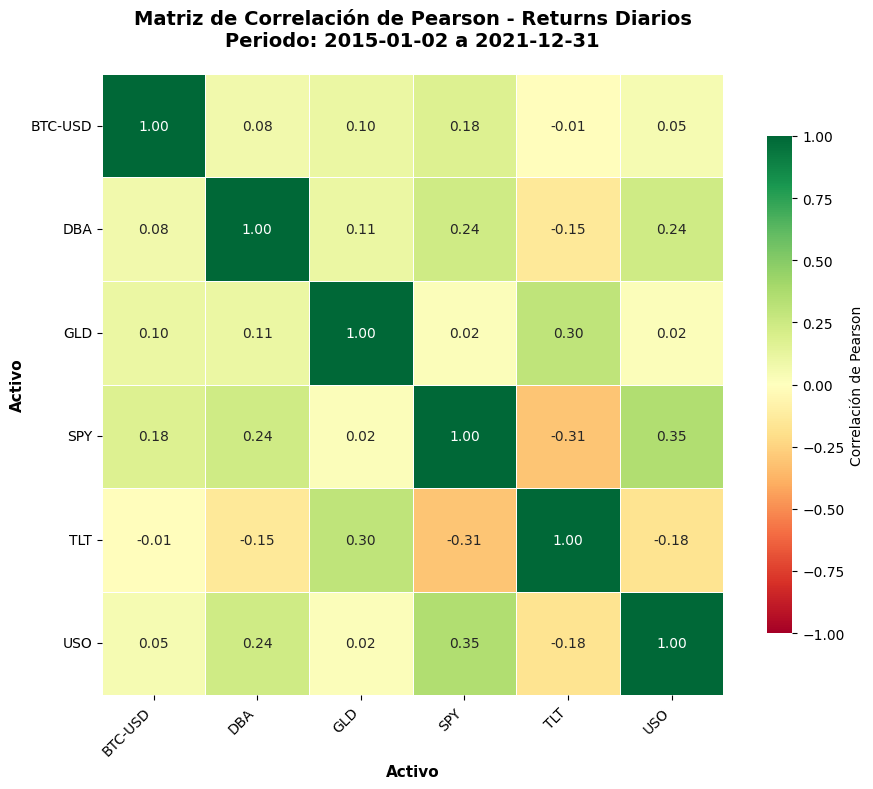


 Matriz de correlación guardada: img6_correlation_matrix_final.png


In [16]:
# VISUALIZACIÓN: MATRIZ DE CORRELACIÓN
print("\n" + "="*80)
print(" GENERANDO VISUALIZACIÓN DE CORRELACIÓN")
print("="*80)

# Crear figura
fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap de correlación
sns.heatmap(
    correlation_matrix,
    annot=True,           # Mostrar valores
    fmt='.2f',            # 2 decimales
    cmap='RdYlGn',        # Colormap: rojo (negativo) → amarillo (0) → verde (positivo)
    center=0,             # Centrar en 0
    vmin=-1,              # Mínimo -1
    vmax=1,               # Máximo +1
    square=True,          # Celdas cuadradas
    linewidths=0.5,       # Líneas entre celdas
    cbar_kws={'label': 'Correlación de Pearson', 'shrink': 0.8},
    ax=ax
)

# Títulos y labels
ax.set_title('Matriz de Correlación de Pearson - Returns Diarios\n' +
             f'Periodo: {DATA_START} a {TRAIN_END}',
             fontweight='bold', fontsize=14, pad=20)
ax.set_xlabel('Activo', fontweight='bold', fontsize=11)
ax.set_ylabel('Activo', fontweight='bold', fontsize=11)

# Rotar labels para mejor legibilidad
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Ajustar layout
plt.tight_layout()

# Guardar
plt.savefig('img6_correlation_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Matriz de correlación guardada: img6_correlation_matrix_final.png")

In [17]:
# GUARDAR RESULTADOS
df_availability.to_csv('asset_availability_report.csv', index=False)
correlation_matrix.to_csv('correlation_matrix_pearson.csv')


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 0.5 VISUALIZACIÓN DE PRECIOS Y REGÍMENES DE MERCADO + JUSTIFICACIÓN DE SPLITS

In [18]:
#TRAIN_END = '2021-12-31'
VAL_START = '2022-01-01'
#VAL_END = '2022-12-31'
TEST_START = '2023-01-01'

**Distribución de datos:**
- TRAIN (2015-2021): 1,723 días (61%) → Bull + COVID crash + Recovery
- VAL (2022): 251 días (9%) → Crisis inflacionaria (año más difícil)
- TEST (2023-2026): 845 días (30%) → Recuperación post-inflación + nuevo régimen.

Los mercados financieros son **no estacionarios**: las correlaciones entre activos cambian con el régimen:
- 2015-2019 (bull): SPY ↑ cuando TLT ↓ (correlación negativa, diversificación funciona)
- 2022 (inflación): SPY ↓ y TLT ↓ simultáneamente (correlación positiva, diversificación falla)
- 2023-2026 (recovery): Dinámicas diferentes, dominadas por tech/IA

El agente debe aprender políticas **dinámicas** adaptadas al régimen actual, no estrategias estáticas que solo funcionan en bull markets.

**Imágenes 7-12: imgx_ACTIVO_precios.jpg**


0.5. VISUALIZACIÓN DE PRECIOS Y REGÍMENES DE MERCADO



/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecat


 Descargados: 4152 días
 Shape: (4152, 6)


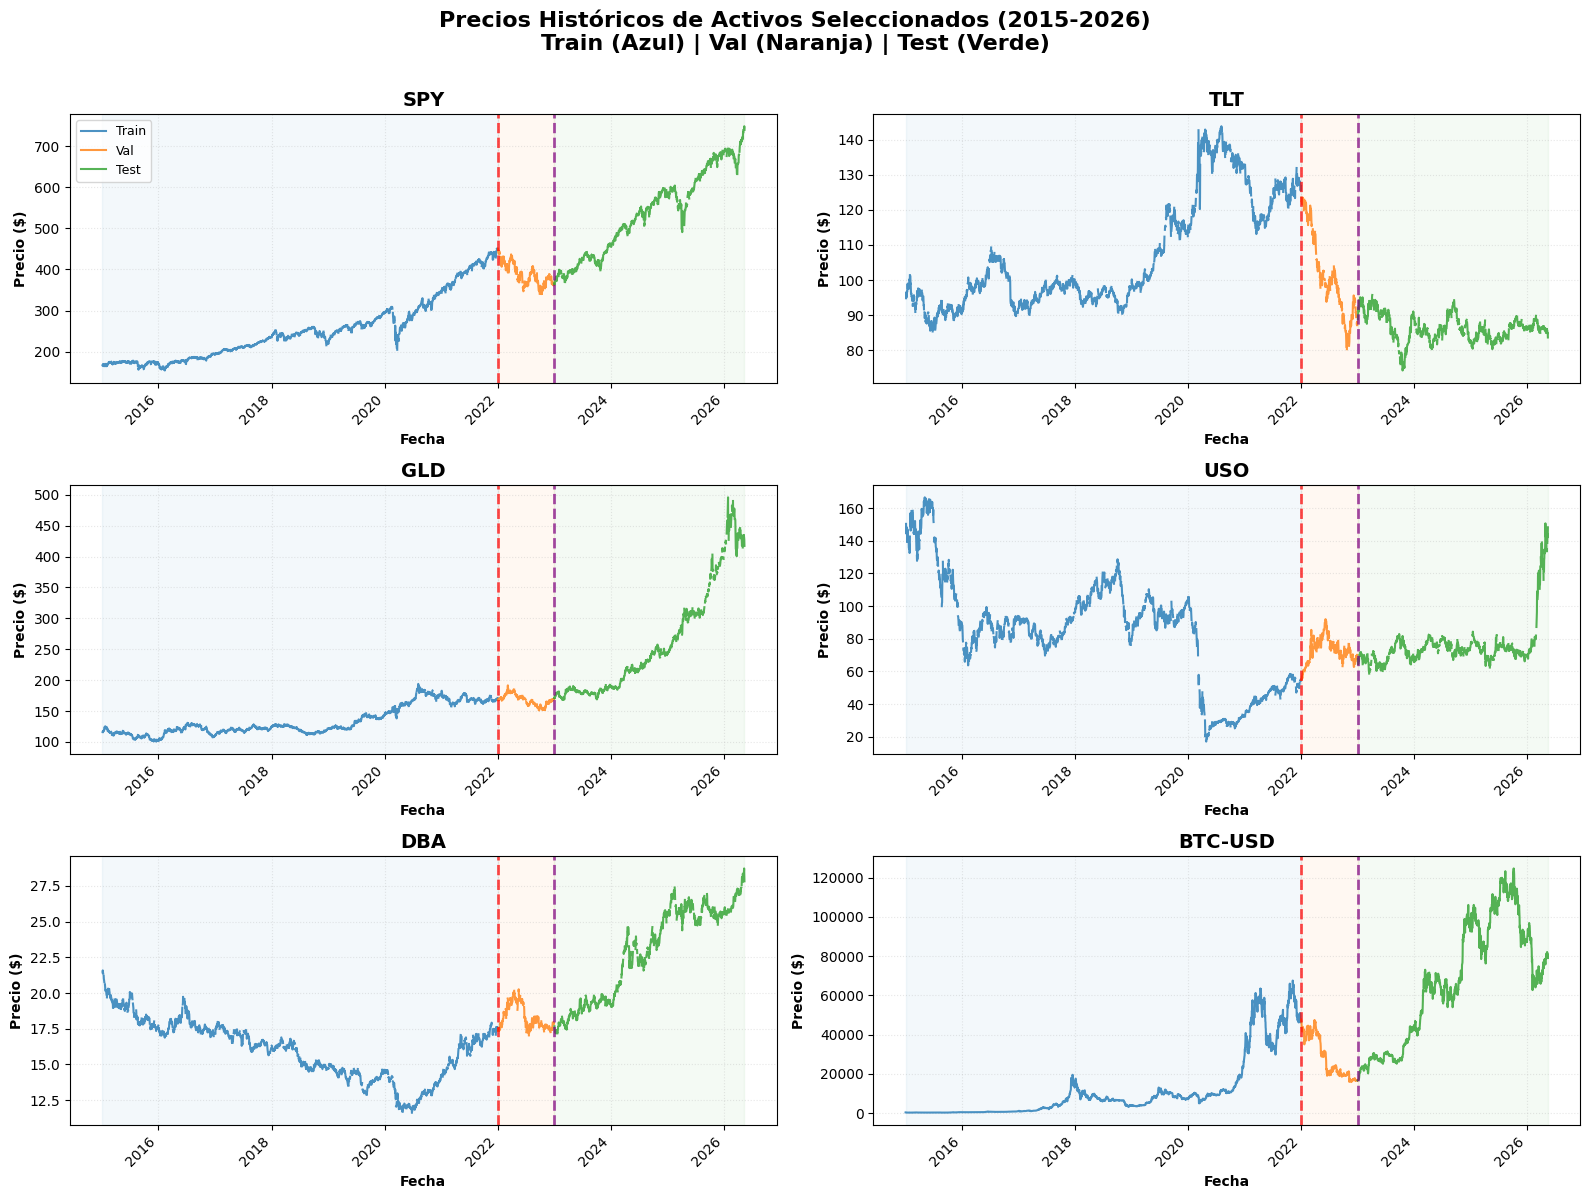

 Guardado: img3_SPY_precios.jpg


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Guardado: img4_TLT_precios.jpg


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Guardado: img5_GLD_precios.jpg


...

 Guardado: img6_USO_precios.jpg


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Guardado: img7_DBA_precios.jpg


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Guardado: img8_BTC_USD_precios.jpg


In [19]:
print("\n" + "=" * 80)
print("0.5. VISUALIZACIÓN DE PRECIOS Y REGÍMENES DE MERCADO")
print("=" * 80 + "\n")

data_viz = yf.download(all_tickers, start=DATA_START, end=DATA_END,
                      auto_adjust=True, progress=False)
prices = data_viz['Close']
print(f"\n Descargados: {len(prices)} días")
print(f" Shape: {prices.shape}")

# Crear figura con 6 subplots
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

# Fechas de separación de splits
train_val_split = pd.to_datetime(VAL_START)
val_test_split = pd.to_datetime(TEST_START)

# Colores por periodo
color_train = '#1f77b4'  # Azul
color_val = '#ff7f0e'    # Naranja
color_test = '#2ca02c'   # Verde

for idx, ticker in enumerate(all_tickers):
    ax = axes[idx]
    price_series = prices[ticker]

    # Dividir en periodos
    train_data = price_series[price_series.index < train_val_split]
    val_data = price_series[(price_series.index >= train_val_split) &
                            (price_series.index < val_test_split)]
    test_data = price_series[price_series.index >= val_test_split]

    # Plotear cada periodo
    ax.plot(train_data.index, train_data.values, color=color_train,
            linewidth=1.5, alpha=0.8, label='Train')
    ax.plot(val_data.index, val_data.values, color=color_val,
            linewidth=1.5, alpha=0.8, label='Val')
    ax.plot(test_data.index, test_data.values, color=color_test,
            linewidth=1.5, alpha=0.8, label='Test')

    # Líneas verticales de separación
    ax.axvline(x=train_val_split, color='red', linestyle='--',
               linewidth=2, alpha=0.7)
    ax.axvline(x=val_test_split, color='purple', linestyle='--',
               linewidth=2, alpha=0.7)

    # Sombreado de periodos
    ax.axvspan(price_series.index[0], train_val_split,
               alpha=0.05, color=color_train)
    ax.axvspan(train_val_split, val_test_split,
               alpha=0.05, color=color_val)
    ax.axvspan(val_test_split, price_series.index[-1],
               alpha=0.05, color=color_test)

    # Formato
    ax.set_title(ticker, fontweight='bold', fontsize=14)
    ax.set_xlabel('Fecha', fontweight='bold')
    ax.set_ylabel('Precio ($)', fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.grid(True, alpha=0.3, linestyle=':')

    if idx == 0:
        ax.legend(loc='upper left', fontsize=9)

fig.suptitle('Precios Históricos de Activos Seleccionados (2015-2026)\n' +
             'Train (Azul) | Val (Naranja) | Test (Verde)',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('precios_activos_finales.png', dpi=150, bbox_inches='tight')
plt.show()


# ── EXPORTAR UNA IMAGEN POR ACTIVO ───────────────────────────────────────────
for idx, ticker in enumerate(all_tickers):
    fig, ax = plt.subplots(figsize=(10, 5))

    price_series = prices[ticker]

    train_data = price_series[price_series.index < train_val_split]
    val_data   = price_series[(price_series.index >= train_val_split) &
                               (price_series.index < val_test_split)]
    test_data  = price_series[price_series.index >= val_test_split]

    ax.plot(train_data.index, train_data.values, color=color_train,
            linewidth=1.5, alpha=0.8, label='Train')
    ax.plot(val_data.index,   val_data.values,   color=color_val,
            linewidth=1.5, alpha=0.8, label='Val')
    ax.plot(test_data.index,  test_data.values,  color=color_test,
            linewidth=1.5, alpha=0.8, label='Test')

    ax.axvline(x=train_val_split, color='red',    linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(x=val_test_split,  color='purple', linestyle='--', linewidth=2, alpha=0.7)

    ax.axvspan(price_series.index[0], train_val_split,  alpha=0.05, color=color_train)
    ax.axvspan(train_val_split,       val_test_split,   alpha=0.05, color=color_val)
    ax.axvspan(val_test_split,        price_series.index[-1], alpha=0.05, color=color_test)

    ax.set_title(f'Precios Históricos — {ticker} (2015-2026)', fontweight='bold', fontsize=14)
    ax.set_xlabel('Fecha', fontweight='bold')
    ax.set_ylabel('Precio ($)', fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.legend(loc='upper left', fontsize=10)

    nombre = f"img{idx+3}_{ticker.replace('-', '_')}_precios.jpg"
    plt.savefig(nombre, dpi=200, bbox_inches='tight', format='jpeg')
    plt.close()
    print(f" Guardado: {nombre}")

- Diversidad de regímenes en Train

Incluye bull market (2015-2019), crash (COVID-2020), y recovery (2020-2021). El agente aprende a operar en condiciones heterogéneas, no solo mercados alcistas.
    
- Validación en periodo adverso

Val (2022) es el año MÁS DIFÍCIL del dataset. Si el modelo overfittea a bull markets, el drawdown en Val será excesivo y será detectado antes del test final.
    
- Test en régimen nuevo

2023-2026 representa un ciclo diferente al de entrenamiento (post-inflación, AI boom). Esto evalúa verdadera generalización, no solo interpolación temporal.
    
Ratio equilibrado 60/10/30, alineado con mejores prácticas en ML financiero (Rasekhschaffe & Jones 2019). Train suficiente para aprendizaje robusto, Test amplio para evaluación estadísticamente significativa.

No data leakage temporal, las features técnicas (RSI, Bollinger, volatilidad) se calculan rolling usando SOLO datos pasados. La normalización (Z-score) se fit en Train y se aplica en Val/Test sin reentrenamiento.
    
Alineación con ciclos de mercado, los splits NO son arbitrarios (e.g., fechas redondas) sino que respetan estructuras de mercado: Train termina en fin de bull crypto (2021), Val captura bear 2022, Test captura nuevo ciclo.

**Análisis por periodo:**

1. **TRAIN (2015-2021):** Incluye el crash más severo del dataset (COVID: SPY -35% en 1 mes) + boom cripto (BTC +900%). Esta diversidad obliga al agente a aprender gestión de riesgo en condiciones heterogéneas.

2. **VAL (2022):** El año más difícil. SPY -18%, TLT -31%, BTC -64%. Si el modelo overfitea a condiciones favorables, su drawdown será excesivo aquí y lo detectaremos antes del test.

3. **TEST (2023-2026):** Régimen nuevo no visto en training. Tipos altos (5% vs 0-2% histórico), correlaciones modificadas, narrativa IA. Mide generalización real, no memorización.


In [20]:
TRAIN_START = '2015-01-02'
TRAIN_END   = '2021-12-31'  # 7 años (bull + COVID + boom)

VAL_START   = '2022-01-01'
VAL_END     = '2022-12-31'  # 1 año (crisis inflación)

TEST_START  = '2023-01-01'
TEST_END    = '2026-05-16'  # 3.4 años (recuperación + normalización)

# Activos
ASSETS = {
    'equity': ['SPY'],
    'bonds': ['TLT'],
    'commodities': ['GLD', 'USO', 'DBA'],
    'crypto': ['BTC-USD']
}

all_tickers = ASSETS['equity'] + ASSETS['bonds'] + ASSETS['commodities'] + ASSETS['crypto']

# Fechas
DATA_START = '2015-01-02'
DATA_END = '2026-05-16'

# Splits (para líneas verticales)
TRAIN_END = '2021-12-31'
VAL_START = '2022-01-01'
VAL_END = '2022-12-31'
TEST_START = '2023-01-01'

##0.7 ANÁLISIS DE MISISNGS

In [21]:
!pip install missingno

In [22]:
#auto_adjust=True fuerza a Yahoo a devolver directamente el precio de cierre ajustado por dividendos/splits
df_descarga = yf.download(all_tickers, start=DATA_START, end=DATA_END, auto_adjust=True)

# Nos quedamos con los precios de cierre limpios (que tras auto_adjust son los ajustados)
df_close = df_descarga['Close']

# Convertir el índice de fechas en una columna normal llamada 'Date' y limpiar el DataFrame
df = df_close.reset_index()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f" Descarga completada con éxito. Filas totales descargadas: {len(df)}\n")

# =====================================================================
# BLOQUE 1: DIAGNÓSTICO GLOBAL (INCLUYENDO BITCOIN)
# =====================================================================
print("  ANÁLISIS GLOBAL DE MISSINGS (TODOS LOS ACTIVOS)")

conteo_global = df[all_tickers].isna().sum()
porcentaje_global = (df[all_tickers].isna().sum() / len(df)) * 100

df_global = pd.DataFrame({
    'NAs Totales': conteo_global,
    'Porcentaje (%)': porcentaje_global.round(2)
})
print(df_global)
print(f"\n Nota: Verás que BTC-USD debería tener 0 missings (o casi 0) porque cotiza 24/7.")
print("-" * 60 + "\n")


# =====================================================================
# BLOQUE 2: ANÁLISIS DE COINCIDENCIA SIN CONTAR BITCOIN
# =====================================================================
print("  ANÁLISIS DE COINCIDENCIA DE MISSINGS (SÓLO ETFS, SIN BTC)")

# Aislamos las columnas de los ETFs tradicionales
etfs_cols = ASSETS['equity'] + ASSETS['bonds'] + ASSETS['commodities']

# Calculamos coincidencias
todos_etfs_missing = df[etfs_cols].isna().all(axis=1)
al_menos_un_etf_missing = df[etfs_cols].isna().any(axis=1)

total_todos_etfs = todos_etfs_missing.sum()
total_al_menos_un_etf = al_menos_un_etf_missing.sum()

print(f"• Días donde TODOS los ETFs faltan a la vez: {total_todos_etfs}")
print(f"• Días donde falla AL MENOS un ETF: {total_al_menos_un_etf}")

if total_todos_etfs == total_al_menos_un_etf:
    print("\n ¡Resultado Perfecto! Los missings de los ETFs coinciden al 100% en las mismas fechas.")
    print("Esto confirma que los huecos ocurren exclusivamente en bloque cuando el mercado tradicional cierra.")
else:
    diferencia = total_al_menos_un_etf - total_todos_etfs
    print(f"\n Asimetría detectada: Hay {diferencia} días donde un ETF falló pero los otros sí cotizaron.")
    print("Esto se debe a festivos específicos de un sector o pequeños desajustes en la carga de datos de Yahoo.")

print("-" * 60 + "\n")

# =====================================================================
# BLOQUE 3: VERIFICACIÓN DEL PATRÓN DE FIN DE SEMANA
# =====================================================================
print("  MUESTRA DE FECHAS CON MISSINGS ")

df_fechas = df[todos_etfs_missing].copy()

if not df_fechas.empty:
    dias_espanol = {
        'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
        'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
    }
    df_fechas['Dia_Semana'] = df_fechas['Date'].dt.day_name().map(dias_espanol)

    print("Primeras 10 fechas detectadas con NAs generalizados en ETFs:")
    print(df_fechas[['Date', 'Dia_Semana']].head(10).to_string(index=False))
else:
    print("No se encontraron registros vacíos simultáneos en los ETFs.")

/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[                       0%                       ]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Times

 Descarga completada con éxito. Filas totales descargadas: 4152

  ANÁLISIS GLOBAL DE MISSINGS (TODOS LOS ACTIVOS)
         NAs Totales  Porcentaje (%)
Ticker                              
SPY             1293           31.14
TLT             1293           31.14
GLD             1293           31.14
USO             1293           31.14
DBA             1293           31.14
BTC-USD            0            0.00

 Nota: Verás que BTC-USD debería tener 0 missings (o casi 0) porque cotiza 24/7.
------------------------------------------------------------

  ANÁLISIS DE COINCIDENCIA DE MISSINGS (SÓLO ETFS, SIN BTC)
• Días donde TODOS los ETFs faltan a la vez: 1293
• Días donde falla AL MENOS un ETF: 1293

 ¡Resultado Perfecto! Los missings de los ETFs coinciden al 100% en las mismas fechas.
Esto confirma que los huecos ocurren exclusivamente en bloque cuando el mercado tradicional cierra.
------------------------------------------------------------

  MUESTRA DE FECHAS CON MISSINGS 
Primeras 1

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Imágenes 13, 14: img13_heatmap_missings.jpg; img14_barras_misisngs.jpg**

In [23]:
# ── GRÁFICO 1: HEATMAP DE MISSINGS ───────────────────────────────────────────
import numpy as np

fig, ax = plt.subplots(figsize=(14, 4))

missing_matrix = df.set_index('Date')[all_tickers].isna().astype(int)

im = ax.imshow(missing_matrix.T, aspect='auto', cmap='RdYlGn_r',
               interpolation='none', vmin=0, vmax=1)

ax.set_yticks(range(len(all_tickers)))
ax.set_yticklabels(all_tickers, fontweight='bold', fontsize=11)
ax.set_title('Mapa de Datos Faltantes por Activo (2015–2026)',
             fontweight='bold', fontsize=13, pad=10)
ax.set_xlabel('Fecha', fontweight='bold')

year_ticks, year_labels = [], []
for year in range(2015, 2027):
    mask = missing_matrix.index.year == year
    if mask.any():
        year_ticks.append(np.where(mask)[0][0])
        year_labels.append(str(year))
ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45, ha='right')

cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Disponible', 'Missing'])

plt.tight_layout()
plt.savefig('img13_heatmap_missings.jpg', dpi=200, bbox_inches='tight', format='jpeg')
plt.close()
print(" Guardado: img13_heatmap_missings.jpg")

# ── GRÁFICO 2: BARRAS % MISSINGS ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

pct    = df[all_tickers].isna().sum() / len(df) * 100
colors = ['#2ecc71' if v < 5 else '#e74c3c' for v in pct.values]
bars   = ax.bar(all_tickers, pct.values, color=colors, edgecolor='white', linewidth=0.8)

ax.set_ylabel('% Missings', fontweight='bold')
ax.set_title('Porcentaje de Datos Faltantes por Activo',
             fontweight='bold', fontsize=13, pad=10)
ax.set_ylim(0, max(pct.values) * 1.3)
ax.grid(axis='y', alpha=0.3, linestyle=':')

for bar, val in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('img14_barras_missings.jpg', dpi=200, bbox_inches='tight', format='jpeg')
plt.close()
print(" Guardado: img14_barras_missings.jpg")

 Guardado: img13_heatmap_missings.jpg
 Guardado: img14_barras_missings.jpg


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Dos opciones: Eliminación por alineación de calendario o Forward Fill (Último valor observado).

* Opción A (La más limpia para carteras multinivel): Eliminar los fines de semana y festivos. Al fin y al cabo, un algoritmo de optimización de carteras necesita rebalancear pesos cuando los mercados están abiertos. Si el mercado tradicional está cerrado, el agente no puede operar los ETFs, por lo que evaluar el estado en domingo carece de sentido operativo.
* Opción B (Forward Fill): Si decides mantener los fines de semana debido a Bitcoin, los ETFs se deben rellenar arrastrando el precio de cierre del viernes hacia el sábado y el domingo. Esto asume que el precio "no se ha movido" porque el mercado está cerrado, respetando estrictamente la causalidad temporal.

La conclusión que se saca es que sí hay missings, la cantidad de 1293 y solo en los activos ETS, ya que son días festivos/fines de semana... momentos en los que el mercado está cerrado. Además hay una buena noticia y es que todos los datos faltantes corresponden al mismo día, por lo que no hya que hacer una limpieza específica a cada uno

# PARTE 1: DESCARGA Y ALINEAMIENTO DE DATOS

OBJETIVO:
---------
Descargar datos históricos OHLCV (Open, High, Low, Close, Volume) para los 6
activos seleccionados y resolver el desafío de sincronización temporal entre
mercados asíncronos: mercados tradicionales (L-V) vs criptomonedas (24/7).

PROBLEMA A RESOLVER:
--------------------
Los activos tradicionales (SPY, TLT, GLD, USO, DBA) solo cotizan durante días
hábiles (lunes a viernes), mientras que Bitcoin (BTC-USD) cotiza continuamente
incluyendo fines de semana y festivos. Esta asincronía genera dos desafíos:

1. **Missing values estructurales:** Los ETFs tienen NaN en sábados/domingos porque
   el mercado está cerrado, pero Bitcoin sigue cotizando.

2. **Data leakage potencial:** Si ignoramos los movimientos de Bitcoin durante el
   fin de semana, perdemos información crítica de volatilidad y momentum.

SOLUCIÓN IMPLEMENTADA:
----------------------
**Acumulación asimétrica hacia el lunes (Asymmetric Weekend Roll-Forward)**

Inspirada en "Modular Reinforcement Learning for Multi-Market Portfolio
Optimization" (2025), esta técnica:

- Usa el calendario bursátil tradicional como eje temporal maestro
- Acumula las métricas de Bitcoin del fin de semana completo (Sáb+Dom+Lun)
- Asigna todo el bloque temporal al lunes siguiente (primer día transaccionable)

Fórmulas de acumulación aplicadas a Bitcoin durante Sáb-Dom-Lun:
  - Open_lunes  = Open_sábado_00:00     (primer precio del bloque)
  - Close_lunes = Close_lunes_23:59     (último precio del bloque)
  - High_lunes  = max(High_sáb, High_dom, High_lun)  (máximo absoluto)
  - Low_lunes   = min(Low_sáb, Low_dom, Low_lun)     (mínimo absoluto)
  - Vol_lunes   = Vol_sáb + Vol_dom + Vol_lun        (volumen total)

  VENTAJAS DE ESTE ENFOQUE:
--------------------------
- No hay data leakage: Solo usamos info pasada (Sáb-Dom) para estado del Lun
- Preserva volatilidad real: High/Low capturan movimientos extremos del weekend
- Sincronización perfecta: Todos los activos tienen las mismas fechas
- Realismo operativo: El agente rebalancea cuando el mercado tradicional abre

In [24]:
# Activos
ASSETS = {
    'equity': ['SPY'],
    'bonds': ['TLT'],
    'commodities': ['GLD', 'USO', 'DBA'],
    'crypto': ['BTC-USD']
}

all_tickers = ASSETS['equity'] + ASSETS['bonds'] + ASSETS['commodities'] + ASSETS['crypto']
crypto_assets = ASSETS['crypto']


# Fechas
DATA_START = '2015-01-02'
DATA_END = '2026-05-16'

# Splits (para líneas verticales)
TRAIN_END = '2021-12-31'
VAL_START = '2022-01-01'
VAL_END = '2022-12-31'
TEST_START = '2023-01-01'

## 1.1 DESCARGA DE DATOS HISTÓRICOS

Dado que los mercados de criptomonedas operan de forma continua mientras que los mercados tradicionales siguen calendarios bursátiles discretos, se adoptó una sincronización temporal basada en el calendario de negociación de los activos tradicionales. Esta decisión permite construir un entorno multi-activo coherente y evita inconsistencias derivadas de la asincronía temporal entre mercados

In [25]:
def download_and_align_portfolio_data_v4(tickers, crypto_tickers, start_date, end_date):
    """
    Descarga y alinea datos financieros de mercados asíncronos (Tradicional vs Crypto).
    Estrategia:
    -----------
    1. Descarga datos brutos de Yahoo Finance para todos los activos
    2. Identifica el calendario bursátil tradicional (días L-V donde SPY cotiza)
    3. Para Bitcoin: Acumula métricas de fin de semana hacia el lunes siguiente
    4. Estructura final: Todas las columnas aplanadas (e.g., 'SPY_Close', 'BTC-USD_Volume')
    Parameters:
    -----------
    tickers : list
        Lista completa de símbolos (tradicionales + crypto)
    crypto_tickers : list
        Subconjunto de tickers que cotizan 24/7
    start_date : str
        Fecha de inicio 'YYYY-MM-DD'
    end_date : str
        Fecha de fin 'YYYY-MM-DD
    Returns:
    --------
    pd.DataFrame
        DataFrame con índice temporal (días hábiles) y columnas aplanadas:
        [SPY_Open, SPY_High, SPY_Low, SPY_Close, SPY_Volume,
         TLT_Open, ..., BTC-USD_Close, BTC-USD_Volume]
    """
    # 1. Descarga de datos brutos
    raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)
    print(f"   Shape bruto: {raw_data.shape}")

    # 2. Extraer calendario bursátil tradicional
    trad_tickers = [t for t in tickers if t not in crypto_tickers]
    price_col = 'Close' if 'Close' in raw_data.columns.levels[0] else 'Adj Close'
    traditional_calendar = raw_data[price_col][trad_tickers[0]].dropna().index

    # 3. Alinear datos tradicionales al calendario
    portfolio_clean = raw_data.loc[traditional_calendar].copy()
    print(portfolio_clean.head(5))

    # 4. Acumulación asimétrica de criptoactivos
    for crypto in crypto_tickers:
        # Extraemos el sub-dataframe de la cripto (OHLCV)
        crypto_data = raw_data.xs(crypto, axis=1, level=1)
        fechas_completas = pd.Series(crypto_data.index, index=crypto_data.index)
        # SÓLO movemos al Lunes si es Sábado (5) o Domingo (6)
        es_fin_de_semana = fechas_completas.dt.dayofweek.isin([5, 6])

        mapeo_inteligente = fechas_completas.copy()
        #Solo movemos al lunes si es fin de semana
        mapeo_inteligente[es_fin_de_semana] = fechas_completas.where(fechas_completas.isin(traditional_calendar)).bfill()

        #Agrupamos por la fecha mapeada
        crypto_grouped = crypto_data.groupby(mapeo_inteligente)

        # Acumular métricas según la estrategia
        portfolio_clean[('Open', crypto)]   = crypto_grouped['Open'].first()    # Open del sábado de madrugada
        portfolio_clean[(price_col, crypto)] = crypto_grouped[price_col].last()  # Close del lunes por la noche
        portfolio_clean[('High', crypto)]   = crypto_grouped['High'].max()      # Máximo absoluto (Sáb + Dom + Lun)
        portfolio_clean[('Low', crypto)]    = crypto_grouped['Low'].min()       # Mínimo absoluto (Sáb + Dom + Lun)
        portfolio_clean[('Volume', crypto)] = crypto_grouped['Volume'].sum()    # Volumen total acumulado

    # 5. Tratamiento de NaNs residuales internos en días laborables comunes
    missings_antes = portfolio_clean.isna().sum().sum()
    print(f"  NaNs antes de limpieza: {missings_antes}")
    if missings_antes > 0:
        portfolio_clean = portfolio_clean.ffill(limit=2).dropna()
        missings_despues = portfolio_clean.isna().sum().sum()
        print(f"   NaNs después de limpieza: {missings_despues}")
        print(f"   Filas eliminadas: {missings_antes - missings_despues}\n")

    # 6. Aplanar estructura de columnas
    # Cambiamos de ('Close', 'SPY') a 'SPY_Close'
    portfolio_clean.columns = [f"{ticker}_{metrica}" for metrica, ticker in portfolio_clean.columns]
    # Ordenar columnas alfabéticamente para mantener consistencia en los vectores de estado
    portfolio_clean = portfolio_clean.sort_index(axis=1)


    #VERIFICACIÓN
    ejemplo_inicio = '2015-01-09'  # Viernes
    ejemplo_fin    = '2015-01-13'  # Martes
    if ejemplo_inicio in portfolio_clean.index and ejemplo_fin in portfolio_clean.index:
        muestra = portfolio_clean[['SPY_Close', 'BTC-USD_Close']].loc[ejemplo_inicio:ejemplo_fin]
        print(muestra)
        print("\n Observa cómo el lunes (2015-01-12) tiene datos para AMBOS activos,")
        print("   reflejando el movimiento acumulado de Bitcoin durante Sáb+Dom+Lun.\n")

    print(f" Shape FINAL: {portfolio_clean.shape} ({portfolio_clean.shape[0]} filas)")
    return portfolio_clean, raw_data

In [26]:
# Llamada a la función estructurada
df_portfolio, raw_data = download_and_align_portfolio_data_v4(
    tickers=all_tickers,
    crypto_tickers=crypto_assets,
    start_date=DATA_START,
    end_date=DATA_END
)

/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWa

   Shape bruto: (4152, 30)
Price            Close                                                \
Ticker         BTC-USD        DBA         GLD         SPY        TLT   
Date                                                                   
2015-01-02  315.032013  21.180378  114.080002  170.124969  93.367340   
2015-01-05  274.473999  21.438255  115.800003  167.052643  94.833992   
2015-01-06  286.188995  21.584389  117.120003  165.479111  96.542648   
2015-01-07  294.337006  21.481236  116.430000  167.541199  96.351959   
2015-01-08  283.348999  21.403872  115.940002  170.514236  95.075928   

Price                         High                                     ...  \
Ticker             USO     BTC-USD        DBA         GLD         SPY  ...   
Date                                                                   ...   
2015-01-02  159.119995  315.838989  21.335105  114.800003  171.325784  ...   
2015-01-05  150.320007  278.341003  21.489830  116.000000  169.247212  ...   
2015-0

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [27]:
df_portfolio.head(5)

,BTC-USD_Close,BTC-USD_High,BTC-USD_Low,BTC-USD_Open,BTC-USD_Volume,DBA_Close,DBA_High,DBA_Low,DBA_Open,DBA_Volume,...,TLT_Close,TLT_High,TLT_Low,TLT_Open,TLT_Volume,USO_Close,USO_High,USO_Low,USO_Open,USO_Volume
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650,21.180378,21.335105,21.120207,21.335105,261800.0,...,93.367340,93.616675,92.509347,92.612013,9432000.0,159.119995,162.800003,157.520004,159.759995,2638313.0
2015-01-05,274.473999,315.149994,257.612000,314.846008,132646300,21.438255,21.489830,21.326507,21.326507,510200.0,...,94.833992,95.061322,93.836660,93.873323,9789500.0,150.320007,154.880005,150.320007,154.639999,3937438.0
2015-01-06,286.188995,287.553009,272.696014,274.610992,23245700,21.584389,21.653156,21.532812,21.592985,345500.0,...,96.542648,97.158652,95.471995,95.845989,18331300.0,144.399994,149.600006,144.000000,148.479996,5279375.0
2015-01-07,294.337006,298.753998,283.079010,286.076996,24866800,21.481236,21.670345,21.481236,21.661751,223300.0,...,96.351959,96.777291,95.457298,95.845961,9762900.0,146.960007,149.199997,144.399994,146.399994,3916575.0
2015-01-08,283.348999,294.135010,282.174988,294.135010,19982500,21.403872,21.653154,21.395275,21.567195,198700.0,...,95.075928,95.603925,94.907266,95.596595,8055300.0,148.399994,148.720001,144.479996,146.240005,3338188.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Imágenes 15,16: img15_sin_mapeo.jpg; img16_mapeo_lunes.jpg**

In [28]:
# ── TABLAS ANTES/DESPUÉS DEL MAPEO ───────────────────────────────────────────
ejemplo_inicio = '2015-01-09'
ejemplo_fin    = '2015-01-14'

# ── TABLA 1: ANTES (datos brutos con NaNs) ────────────────────────────────────
btc_cols_raw = ['Open', 'High', 'Low', 'Close', 'Volume']
antes = raw_data.loc[ejemplo_inicio:ejemplo_fin,
                     pd.IndexSlice[btc_cols_raw, ['SPY', 'BTC-USD']]].copy()
antes.columns = [f"{ticker}_{col}" for col, ticker in antes.columns]
antes = antes[['SPY_Close', 'BTC-USD_Open', 'BTC-USD_High',
                'BTC-USD_Low', 'BTC-USD_Close', 'BTC-USD_Volume']]

# Añadir columna Día ANTES de formatear el índice
dia_map = {'Monday':'Lunes','Tuesday':'Martes','Wednesday':'Miércoles',
           'Thursday':'Jueves','Friday':'Viernes','Saturday':'Sábado','Sunday':'Domingo'}
dias = antes.index.day_name().map(dia_map)

# Formatear valores
def fmt(x): return f"{x:.2f}" if pd.notna(x) else 'NaN'
def fmt_vol(x): return f"{int(x):,}" if pd.notna(x) else 'NaN'

cell_data_antes = []
for i, (fecha, dia) in enumerate(zip(antes.index.strftime('%Y-%m-%d'), dias)):
    row = antes.iloc[i]
    cell_data_antes.append([
        fecha, dia,
        fmt(row['SPY_Close']),
        fmt(row['BTC-USD_Open']), fmt(row['BTC-USD_High']),
        fmt(row['BTC-USD_Low']),  fmt(row['BTC-USD_Close']),
        fmt_vol(row['BTC-USD_Volume'])
    ])

col_labels = ['Fecha', 'Día', 'SPY Close', 'BTC Open', 'BTC High', 'BTC Low', 'BTC Close', 'BTC Volume']
col_widths  = [0.14, 0.10, 0.12, 0.12, 0.12, 0.12, 0.12, 0.14]

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.axis('off')
tabla = ax.table(
    cellText=cell_data_antes,
    colLabels=col_labels,
    loc='center', cellLoc='center',
    colWidths=col_widths
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1, 2.0)

for j in range(8):
    tabla[0, j].set_facecolor('#2D6A9F')
    tabla[0, j].set_text_props(color='white', fontweight='bold')
    tabla[0, j].set_edgecolor('#1E3A5F')

for i, row in enumerate(cell_data_antes):
    es_finde = row[1] in ['Sábado', 'Domingo']
    for j in range(8):
        tabla[i+1, j].set_edgecolor('#BDC3C7')
        if es_finde:
            tabla[i+1, j].set_facecolor('#FADBD8')
            tabla[i+1, j].set_text_props(fontweight='bold', color='#c0392b')
        else:
            tabla[i+1, j].set_facecolor('#EBF5FB')

plt.title('ANTES del Mapeo — SPY tiene NaN en Fin de Semana',
          fontweight='bold', fontsize=12, pad=8, color='#1A2B3C')
plt.tight_layout()
plt.savefig('img15_sin_mapeo.jpg', dpi=200, bbox_inches='tight', format='jpeg')
plt.close()
print(" Guardado: img15_sin_mapeo.jpg")

# ── TABLA 2: DESPUÉS (datos alineados, solo días hábiles) ────────────────────
btc_cols_port = ['BTC-USD_Open', 'BTC-USD_High', 'BTC-USD_Low', 'BTC-USD_Close', 'BTC-USD_Volume']
despues = df_portfolio[['SPY_Close'] + btc_cols_port].loc[ejemplo_inicio:ejemplo_fin].copy()
dias_despues = despues.index.day_name().map(dia_map)

cell_data_despues = []
for i, (fecha, dia) in enumerate(zip(despues.index.strftime('%Y-%m-%d'), dias_despues)):
    row = despues.iloc[i]
    cell_data_despues.append([
        fecha, dia,
        fmt(row['SPY_Close']),
        fmt(row['BTC-USD_Open']), fmt(row['BTC-USD_High']),
        fmt(row['BTC-USD_Low']),  fmt(row['BTC-USD_Close']),
        fmt_vol(row['BTC-USD_Volume'])
    ])

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.axis('off')
tabla = ax.table(
    cellText=cell_data_despues,
    colLabels=col_labels,
    loc='center', cellLoc='center',
    colWidths=col_widths
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1, 2.0)

for j in range(8):
    tabla[0, j].set_facecolor('#2D6A9F')
    tabla[0, j].set_text_props(color='white', fontweight='bold')
    tabla[0, j].set_edgecolor('#1E3A5F')

for i, row in enumerate(cell_data_despues):
    es_lunes = row[1] == 'Lunes'
    for j in range(8):
        tabla[i+1, j].set_edgecolor('#BDC3C7')
        if es_lunes:
            tabla[i+1, j].set_facecolor('#D5F5E3')
            tabla[i+1, j].set_text_props(fontweight='bold', color='#1e8449')
        else:
            tabla[i+1, j].set_facecolor('#EBF5FB')

plt.title('DESPUÉS del Mapeo — BTC acumulado al Lunes, sin NaNs',
          fontweight='bold', fontsize=12, pad=8, color='#1A2B3C')
plt.tight_layout()
plt.savefig('img16_mapeo_lunes.jpg', dpi=200, bbox_inches='tight', format='jpeg')
plt.close()
print(" Guardado: img16_mapeo_lunes.jpg")

 Guardado: img15_sin_mapeo.jpg
 Guardado: img16_mapeo_lunes.jpg


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#PARTE 2: INGIENERÍA DE FEATURES

OBJETIVO:
---------
Transformar los precios OHLCV brutos en un espacio de estados rico y estable para el agente de Deep Reinforcement Learning. En lugar de usar precios directos (que tienen tendencias no estacionarias), calculamos 50 indicadores técnicos
normalizados que capturan momentum, volatilidad, microestructura y régimen de mercado.

FILOSOFÍA DE DISEÑO:
--------------------
**Reducción dimensional estratégica:** En lugar de calcular 16 indicadores por activo (96 features totales), usamos solo 8 indicadores cuidadosamente seleccionados por activo (48 features individuales) + 2 features globales = 50 features totales.

**Justificación:** Espacios de estados masivos (>100 dimensiones) con alta multicolinealidad generan:

  • Gradientes ruidosos que ralentizan convergencia de PPO

  • Overfitting por aprender correlaciones espurias

  • Mayor costo computacional sin mejora en desempeño


FEATURES SELECCIONADAS (8 POR ACTIVO):
--------------------------------------
1. **r1, r5, r20** (Retornos logarítmicos multi-escala)

→ Captura momentum a corto (1d), medio (5d) y largo plazo (20d)

2. **vol** (Volatilidad anualizada 20 días)

→ Estima riesgo realizado reciente


3. **rsi** (Relative Strength Index, normalizado 0-1)
   
→ Identifica condiciones de sobrecompra (>0.7) y sobreventa (<0.3)


4. **bb** (Bollinger %B)

→ Posición del precio dentro de las bandas de volatilidad

→ bb=0 → precio en banda inferior, bb=1 → banda superior

→ Captura desviaciones extremas de la media móvil

5. **vnorm** (Volumen normalizado)

→ Detecta picos de liquidez (>2 = volumen anómalo)

6. **hlrange** (Rango High-Low normalizado)

→ Mide volatilidad intradiaria relativa al precio

FEATURES GLOBALES (2):
----------------------
7. **GLOBAL_Market_Correlation** (Correlación promedio entre activos, 20d)

→ Detecta cambios de régimen (correlaciones altas = crisis sistémica)

8. **GLOBAL_Is_Monday** (Indicador binario de lunes)

→ Captura efectos de calendario (e.g., acumulación de weekend en Bitcoin)
   

VENTANA TEMPORAL Y DATA LEAKAGE:
---------------------------------
¿Calcular features sobre la serie completa ANTES de
hacer el split Train/Val/Test produce data leakage?

NO, porque las funciones de rolling (media móvil, RSI, volatilidad)
son operadores **causales** que SOLO miran hacia atrás en el tiempo.

Ejemplo concreto:
  • Fecha: 2022-01-03 (primer día de VAL)
  • RSI(14): Calcula usando precios de 2021-12-06 a 2022-01-03
  • ¿Usa datos futuros? NO, solo usa su propio pasado histórico
  • ¿Es realista? SÍ, en producción el agente tendría acceso al mismo histórico

**Ventaja metodológica:** Al calcular sobre la serie continua, el primer día de VAL y TEST tiene sus features completas (no pierde el primer mes por warm-up).

LIMPIEZA DE DATOS:
------------------
1. **Winsorización (1%-99%):** Corta outliers extremos para evitar que valores anómalos (e.g., flash crash) dominen el entrenamiento.

2. **Eliminación de NaNs:** Las primeras ~20 filas se pierden debido a ventanas rolling (trade-off aceptable: 20 días vs 2,800+ días totales).

3. **Detección de infinitos:** Reemplaza ±inf por NaN antes de eliminar filas.



In [29]:
def compute_features_v10_robust(df, tickers):
    """
    Calcula 50 features técnicas optimizadas para Deep Reinforcement Learning.

    Arquitectura del espacio de estados:
    ------------------------------------
    • 8 features por activo × 6 activos = 48 features individuales
    • 2 features globales del sistema = 2 features de mercado
    • TOTAL: 50 dimensiones (espacio de estados compacto y eficiente)

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame con columnas aplanadas (e.g., 'SPY_Close', 'BTC-USD_Volume')
        Debe contener OHLCV para todos los activos

    tickers : list
        Lista de símbolos de activos (e.g., ['SPY', 'TLT', ..., 'BTC-USD'])

    Returns:
    --------
    pd.DataFrame
        DataFrame con 50 columnas de features normalizadas y ~20 filas menos
        que el input original (pérdida por ventanas rolling de 20 días)

    Features generadas por activo:
    -------------------------------
    {TICKER}_r1       : Retorno logarítmico 1 día
    {TICKER}_r5       : Retorno logarítmico 5 días
    {TICKER}_r20      : Retorno logarítmico 20 días
    {TICKER}_vol      : Volatilidad anualizada (20d)
    {TICKER}_rsi      : RSI normalizado (0-1)
    {TICKER}_bb       : Bollinger %B (posición en bandas)
    {TICKER}_vnorm    : Volumen normalizado por media móvil 20d
    {TICKER}_hlrange  : Rango High-Low / Close (volatilidad intraday)

    Features globales:
    ------------------
    GLOBAL_Market_Correlation : Correlación promedio entre activos (20d)
    GLOBAL_Is_Monday         : Indicador binario (1=lunes, 0=otro día)
    """
    features_list = []

    # A. CARACTERÍSTICAS INDIVIDUALES POR ACTIVO
    for ticker in tickers:
        print(f" Procesando: {ticker}")

        # Extraer columnas OHLCV del activo actual
        close = df[f"{ticker}_Close"]
        high = df[f"{ticker}_High"]
        low = df[f"{ticker}_Low"]
        volume = df[f"{ticker}_Volume"]

        # 1. RETORNOS LOGARÍTMICOS MULTI-ESCALA
        # Fórmula: r_t = ln(P_t / P_{t-n})
        #Ventaja vs retornos simples: Simetría matemática (r_up = -r_down) y aditivos en el tiempo
        r1 = np.log(close / close.shift(1))
        r5 = np.log(close / close.shift(5))
        r20 = np.log(close / close.shift(20))

        # 2. VOLATILIDAD ANUALIZADA
        # Fórmula: σ_annual = σ_daily × √252
        # Mide dispersión de retornos en ventana de 20 días, anualizada
        vol = r1.rolling(20).std() * np.sqrt(252)

        # 3. RSI - RELATIVE STRENGTH INDEX
        # Oscilador de momentum que mide velocidad y magnitud de cambios de precio
        # Fórmula: RSI = 100 - (100 / (1 + RS)), donde RS = avg_gain / avg_loss
        # Interpretación: RSI > 70 → Sobrecompra, RSI < 30 → Sobreventa
        rsi_raw = ta.rsi(close, length=14) # pandas_ta devuelve valores 0-100
        rsi = rsi_raw / 100.0  # Normalizado entre 0 y 1

        # 4. BOLLINGER %B
        # Posición del precio dentro de las Bandas de Bollinger
        # Fórmula: %B = (Close - LowerBand) / (UpperBand - LowerBand)
        # Valores: %B = 0 → precio en banda inferior
        #          %B = 0.5 → precio en media móvil
        #          %B = 1 → precio en banda superior
        #          %B > 1 o < 0 → precio fuera de bandas (extremo)

        bb = ta.bbands(close, length=20, std=2) # Bandas ±2 desviaciones estándar

        if bb is not None:
            # Detectar automáticamente los nombres reales de las columnas
            bb_cols = bb.columns.tolist()
            # Buscar la columna que contenga 'BBP' (Bollinger Band Percent)
            bbp_col = [col for col in bb_cols if 'BBP' in col]

            if len(bbp_col) > 0:
                # Usamos el %B que calcula pandas_ta
                bb_pct = bb[bbp_col[0]]
                print(f"  Usando columna {bbp_col[0]} para Bollinger %B")
            else:
                # Si no existe BBP, calculamos manualmente desde BBU y BBL
                bbu_col = [col for col in bb_cols if 'BBU' in col][0]
                bbl_col = [col for col in bb_cols if 'BBL' in col][0]

                bb_upper = bb[bbu_col]
                bb_lower = bb[bbl_col]

                # Cálculo del %B = (Close - Lower) / (Upper - Lower)
                band_width = (bb_upper - bb_lower).replace(0, np.nan)
                bb_pct = (close - bb_lower) / band_width
                bb_pct = bb_pct.fillna(0.5)  # Rellenar NaNs con 0.5
        else:
            # Fallback completo: Cálculo manual desde cero
            print(f" pandas_ta.bbands() devolvió None, calculando manualmente")
            bb_middle = close.rolling(20).mean()
            bb_std = close.rolling(20).std()
            bb_upper = bb_middle + (2 * bb_std)
            bb_lower = bb_middle - (2 * bb_std)

            band_width = (bb_upper - bb_lower).replace(0, np.nan)
            bb_pct = (close - bb_lower) / band_width
            bb_pct = bb_pct.fillna(0.5)

        # 5. VOLUMEN NORMALIZADO
        # Ratio del volumen actual vs promedio de 20 días
        # Valores: vnorm = 1 → volumen normal
        #          vnorm > 2 → spike de liquidez (posible evento importante)
        #          vnorm < 0.5 → volumen anormalmente bajo
        vol_norm = volume / (volume.rolling(20).mean() + 1e-10)

        # 6. RANGO HIGH-LOW NORMALIZADO
        # Mide volatilidad intradiaria relativa al precio de cierre
        # Valores altos → día muy volátil (gran oscilación High-Low)
        # Captura microestructura no visible en retornos Close-to-Close
        hl_range = (high - low) / (close + 1e-10)

        # Combinar en DataFrame
        df_ticker = pd.DataFrame({
            f'{ticker}_r1': r1,
            f'{ticker}_r5': r5,
            f'{ticker}_r20': r20,
            f'{ticker}_vol': vol,
            f'{ticker}_rsi': rsi,
            f'{ticker}_bb': bb_pct,
            f'{ticker}_vnorm': vol_norm,
            f'{ticker}_hlrange': hl_range
        }, index=df.index)

        features_list.append(df_ticker)

    # Concatenar características individuales
    all_features = pd.concat(features_list, axis=1)

    # B. CARACTERÍSTICAS GLOBALES DEL SISTEMA
    # Extraer retornos diarios de todos los activos para correlación
    retornos_todos = pd.DataFrame({
        t: np.log(df[f"{t}_Close"] / df[f"{t}_Close"].shift(1))
        for t in tickers
    }, index=df.index)

    # 7. CORRELACIÓN MEDIA RODANTE DEL MERCADO (ROLLING 20 DÍAS)
    # Calcula la correlación promedio entre todos los pares de activos
    # Interpretación:
    #   • Correlación alta (>0.7) → Movimientos sincronizados (régimen de crisis)
    #   • Correlación baja (<0.3) → Activos descorrelacionados (oportunidad diversificación)
    rolling_corr = retornos_todos.rolling(20).corr()
    mean_corr_list = []

    for date in df.index:
        if date in rolling_corr.index.get_level_values(0):
            matrix = rolling_corr.loc[date] # Matriz de correlación 6×6 para esa fech
            # Extraer valores fuera de la diagonal principal
            mask = ~np.eye(matrix.shape[0], dtype=bool)
            mean_corr_list.append(matrix.values[mask].mean())
        else:
            mean_corr_list.append(np.nan)

    all_features['GLOBAL_Market_Correlation'] = pd.Series(mean_corr_list, index=df.index)

    # 8. INDICADOR DE LUNES
    # Variable binaria que marca los lunes (día de acumulación de weekend para Bitcoin)
    # Captura efectos de calendario documentados en literatura (Monday effect)
    all_features['GLOBAL_Is_Monday'] = (df.index.dayofweek == 0).astype(float)

    # C. LIMPIEZA ROBUSTA Y WINSORIZACIÓN (para asegurar)
    # 1. Reemplazar infinitos por NaN
    all_features.replace([np.inf, -np.inf], np.nan, inplace=True) # Operaciones como división por cero pueden generar ±inf

    # 2. Forward-fill para GLOBAL_Market_Correlation
    all_features['GLOBAL_Market_Correlation'] = all_features['GLOBAL_Market_Correlation'].ffill()

    # 3. Eliminar filas con NaNs
    all_features_clean = all_features.dropna()

    # 4. WINSORIZACIÓN: Cortar outliers extremos al percentil 1% y 99%
    for col in all_features_clean.columns:
        if col != 'GLOBAL_Is_Monday':  # No winsorizar variable binaria
            p01 = all_features_clean[col].quantile(0.01)
            p99 = all_features_clean[col].quantile(0.99)
            all_features_clean[col] = all_features_clean[col].clip(lower=p01, upper=p99)


    # RESUMEN FINAL
    print(f"\n Matriz de observaciones completada.")
    print(f" Espacio de Estados: {all_features_clean.shape[1]} variables × {len(all_features_clean)} timesteps")
    print(f" Composición: 8 features/activo × {len(tickers)} activos + 2 globales = {all_features_clean.shape[1]} features")
    print(f" Pérdida de histórico: {len(df) - len(all_features_clean)} días (~20 por ventanas rodantes)")
    print(f" Rango temporal: {all_features_clean.index[0]} → {all_features_clean.index[-1]}")

    return all_features_clean

In [30]:
print("2.3. GENERACIÓN DEL ESPACIO DE ESTADOS")
df_features = compute_features_v10_robust(df_portfolio, all_tickers)

2.3. GENERACIÓN DEL ESPACIO DE ESTADOS
 Procesando: SPY
  Usando columna BBP_20_2.0_2.0 para Bollinger %B
 Procesando: TLT
  Usando columna BBP_20_2.0_2.0 para Bollinger %B
 Procesando: GLD
  Usando columna BBP_20_2.0_2.0 para Bollinger %B
 Procesando: USO
  Usando columna BBP_20_2.0_2.0 para Bollinger %B
 Procesando: DBA
  Usando columna BBP_20_2.0_2.0 para Bollinger %B
 Procesando: BTC-USD
  Usando columna BBP_20_2.0_2.0 para Bollinger %B


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



 Matriz de observaciones completada.
 Espacio de Estados: 50 variables × 2839 timesteps
 Composición: 8 features/activo × 6 activos + 2 globales = 50 features
 Pérdida de histórico: 20 días (~20 por ventanas rodantes)
 Rango temporal: 2015-02-02 00:00:00 → 2026-05-15 00:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [31]:
df_features.head(10)

,SPY_r1,SPY_r5,SPY_r20,SPY_vol,SPY_rsi,SPY_bb,SPY_vnorm,SPY_hlrange,TLT_r1,TLT_r5,...,BTC-USD_r1,BTC-USD_r5,BTC-USD_r20,BTC-USD_vol,BTC-USD_rsi,BTC-USD_bb,BTC-USD_vnorm,BTC-USD_hlrange,GLOBAL_Market_Correlation,GLOBAL_Is_Monday
Date,,,,,,,,,,,,,,,,,,,,,
2015-02-02,0.012308,-0.017331,-0.017234,0.175337,0.303316,0.441341,1.011470,0.020652,-0.003783,0.024975,...,0.050819,-0.137970,-0.279442,1.482108,0.251754,0.450950,1.478452,0.126601,-0.068727,1.0
2015-02-03,0.014357,0.010304,0.015348,0.170624,0.363838,0.766308,0.781280,0.011228,-0.021394,0.002020,...,-0.047102,-0.147829,-0.188727,1.482108,0.245349,0.382646,0.790279,0.094488,-0.062017,0.0
2015-02-04,-0.003815,0.019397,0.020997,0.167277,0.354967,0.655944,0.865132,0.009164,0.001708,-0.012488,...,-0.001828,-0.030656,-0.232350,1.482108,0.245349,0.397564,0.513660,0.039431,-0.059743,0.0
2015-02-05,0.010045,0.020241,0.018657,0.165369,0.396796,0.860595,0.636579,0.007423,-0.011041,-0.016927,...,-0.043894,-0.072829,-0.304317,1.482108,0.245349,0.335048,0.435886,0.113675,-0.058138,0.0
2015-02-06,-0.002769,0.030126,-0.001701,0.153539,0.389274,0.800662,0.822476,0.011287,-0.017860,-0.047271,...,0.023466,-0.018539,-0.242804,1.482108,0.248840,0.400866,0.471003,0.064238,-0.065826,0.0
2015-02-09,-0.004486,0.013332,0.001859,0.151599,0.376856,0.690949,0.584461,0.007330,-0.001605,-0.047271,...,-0.009747,-0.079105,-0.277159,1.482108,0.246523,0.398777,1.226096,0.060333,-0.064892,1.0
2015-02-10,0.010597,0.009571,0.020320,0.152904,0.423764,0.888667,0.654988,0.011798,-0.007986,-0.036783,...,-0.001232,-0.033234,-0.197330,1.482108,0.246213,0.415673,0.400599,0.029453,-0.063168,0.0
2015-02-11,0.000580,0.013966,0.023717,0.152249,0.426323,0.856010,0.647644,0.007829,0.001848,-0.036643,...,-0.002979,-0.034386,-0.030004,1.358593,0.245410,0.411888,0.399266,0.024326,-0.072306,0.0
2015-02-12,0.009571,0.013493,0.039343,0.152496,0.468493,0.976369,0.717922,0.009669,-0.003315,-0.028917,...,0.011698,0.021205,0.219252,1.033353,0.255719,0.398914,0.399266,0.020675,-0.055325,0.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#VER Q HACER CONE STOS GRÁFICOS

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# GRÁFICO 1: HEATMAP DE CORRELACIÓN ENTRE LAS 50 FEATURES
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(18, 15))

corr_matrix = df_features.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Solo triángulo inferior

sns.heatmap(corr_matrix, ax=ax, mask=mask,
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Correlación', 'shrink': 0.8})

ax.set_title('Matriz de Correlación — Espacio de Estados (50 Features)',
             fontweight='bold', fontsize=14, pad=15)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig('img_heatmap_correlacion_features.jpg', dpi=200, bbox_inches='tight', format='jpeg')
plt.close()
print(" Guardado: img_heatmap_correlacion_features.jpg")

# ══════════════════════════════════════════════════════════════════════════════
# GRÁFICO 2: VIOLIN PLOTS — DISTRIBUCIÓN DE FEATURES POR ACTIVO
# ══════════════════════════════════════════════════════════════════════════════
features_plot = ['_r1', '_vol', '_rsi', '_bb']
feature_names = ['Retorno Diario (r1)', 'Volatilidad Anualizada', 'RSI (norm.)', 'Bollinger %B']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#2D6A9F', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c']

for idx, (feat, name) in enumerate(zip(features_plot, feature_names)):
    ax = axes[idx]
    data_plot = [df_features[f'{t}{feat}'].dropna().values for t in all_tickers]

    parts = ax.violinplot(data_plot, positions=range(len(all_tickers)),
                          showmedians=True, showextrema=True)

    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i % len(colors)])
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)

    ax.set_xticks(range(len(all_tickers)))
    ax.set_xticklabels(all_tickers, fontsize=10, fontweight='bold')
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.suptitle('Distribución de Features por Activo — Verificación de Winsorización',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('img_violin_features.jpg', dpi=200, bbox_inches='tight', format='jpeg')
plt.close()
print(" Guardado: img_violin_features.jpg")

# ══════════════════════════════════════════════════════════════════════════════
# GRÁFICO 3: CORRELACIÓN DINÁMICA DEL MERCADO
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))

corr_series = df_features['GLOBAL_Market_Correlation']
ax.plot(corr_series.index, corr_series.values,
        color='#6c3483', linewidth=1.5, alpha=0.9, label='Correlación media (20d)')
ax.fill_between(corr_series.index, corr_series.values, 0,
                where=(corr_series.values > 0), alpha=0.15, color='#e74c3c', label='Correlación positiva')
ax.fill_between(corr_series.index, corr_series.values, 0,
                where=(corr_series.values < 0), alpha=0.15, color='#2ecc71', label='Correlación negativa')

# Marcar eventos clave
eventos = {
    'COVID-19\n(Mar 2020)': '2020-03-15',
    'Crash Crypto\n(Nov 2022)': '2022-11-10',
}
for label, fecha in eventos.items():
    if pd.to_datetime(fecha) in corr_series.index or True:
        ax.axvline(pd.to_datetime(fecha), color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.text(pd.to_datetime(fecha), corr_series.max() * 0.9, label,
                fontsize=8, color='gray', ha='center')

ax.axhline(0.7, color='red',   linestyle=':', linewidth=1, alpha=0.6, label='Umbral crisis (0.7)')
ax.axhline(0.3, color='green', linestyle=':', linewidth=1, alpha=0.6, label='Umbral diversif. (0.3)')
ax.axhline(0,   color='black', linestyle='-', linewidth=0.5)

ax.set_title('Correlación Dinámica del Mercado (Rolling 20d) — Régimen de Mercado',
             fontweight='bold', fontsize=13, pad=10)
ax.set_ylabel('Correlación Media', fontweight='bold')
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3, linestyle=':')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.savefig('img_correlacion_dinamica.jpg', dpi=200, bbox_inches='tight', format='jpeg')
plt.close()
print(" Guardado: img_correlacion_dinamica.jpg")

# ══════════════════════════════════════════════════════════════════════════════
# GRÁFICO 4: TABLA RESUMEN ESTADÍSTICAS DESCRIPTIVAS
# ══════════════════════════════════════════════════════════════════════════════
stats = df_features.describe().T[['mean', 'std', 'min', 'max']].round(4)
stats.columns = ['Media', 'Std', 'Mín', 'Máx']
stats = stats.reset_index().rename(columns={'index': 'Feature'})

n_cols  = 5
n_rows  = len(stats)
fig_h   = max(6, n_rows * 0.35 + 1.5)

fig, ax = plt.subplots(figsize=(13, fig_h))
ax.axis('off')

tabla = ax.table(
    cellText=stats.values,
    colLabels=stats.columns.tolist(),
    loc='center', cellLoc='center',
    colWidths=[0.35, 0.16, 0.16, 0.16, 0.16]
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(8)
tabla.scale(1, 1.4)

for j in range(n_cols):
    tabla[0, j].set_facecolor('#2D6A9F')
    tabla[0, j].set_text_props(color='white', fontweight='bold')
    tabla[0, j].set_edgecolor('#1E3A5F')

for i in range(len(stats)):
    bg = '#EBF5FB' if i % 2 == 0 else '#FDFEFE'
    for j in range(n_cols):
        tabla[i+1, j].set_facecolor(bg)
        tabla[i+1, j].set_edgecolor('#BDC3C7')

plt.title('Estadísticas Descriptivas — Espacio de Estados (50 Features)',
          fontweight='bold', fontsize=12, pad=8, color='#1A2B3C')
plt.tight_layout()
plt.savefig('img_tabla_estadisticas_features.jpg', dpi=200, bbox_inches='tight', format='jpeg')
plt.close()
print(" Guardado: img_tabla_estadisticas_features.jpg")

 Guardado: img_heatmap_correlacion_features.jpg


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Guardado: img_violin_features.jpg


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Guardado: img_correlacion_dinamica.jpg


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Guardado: img_tabla_estadisticas_features.jpg


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



 Gráficos guardados en: feature_diagnostics.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


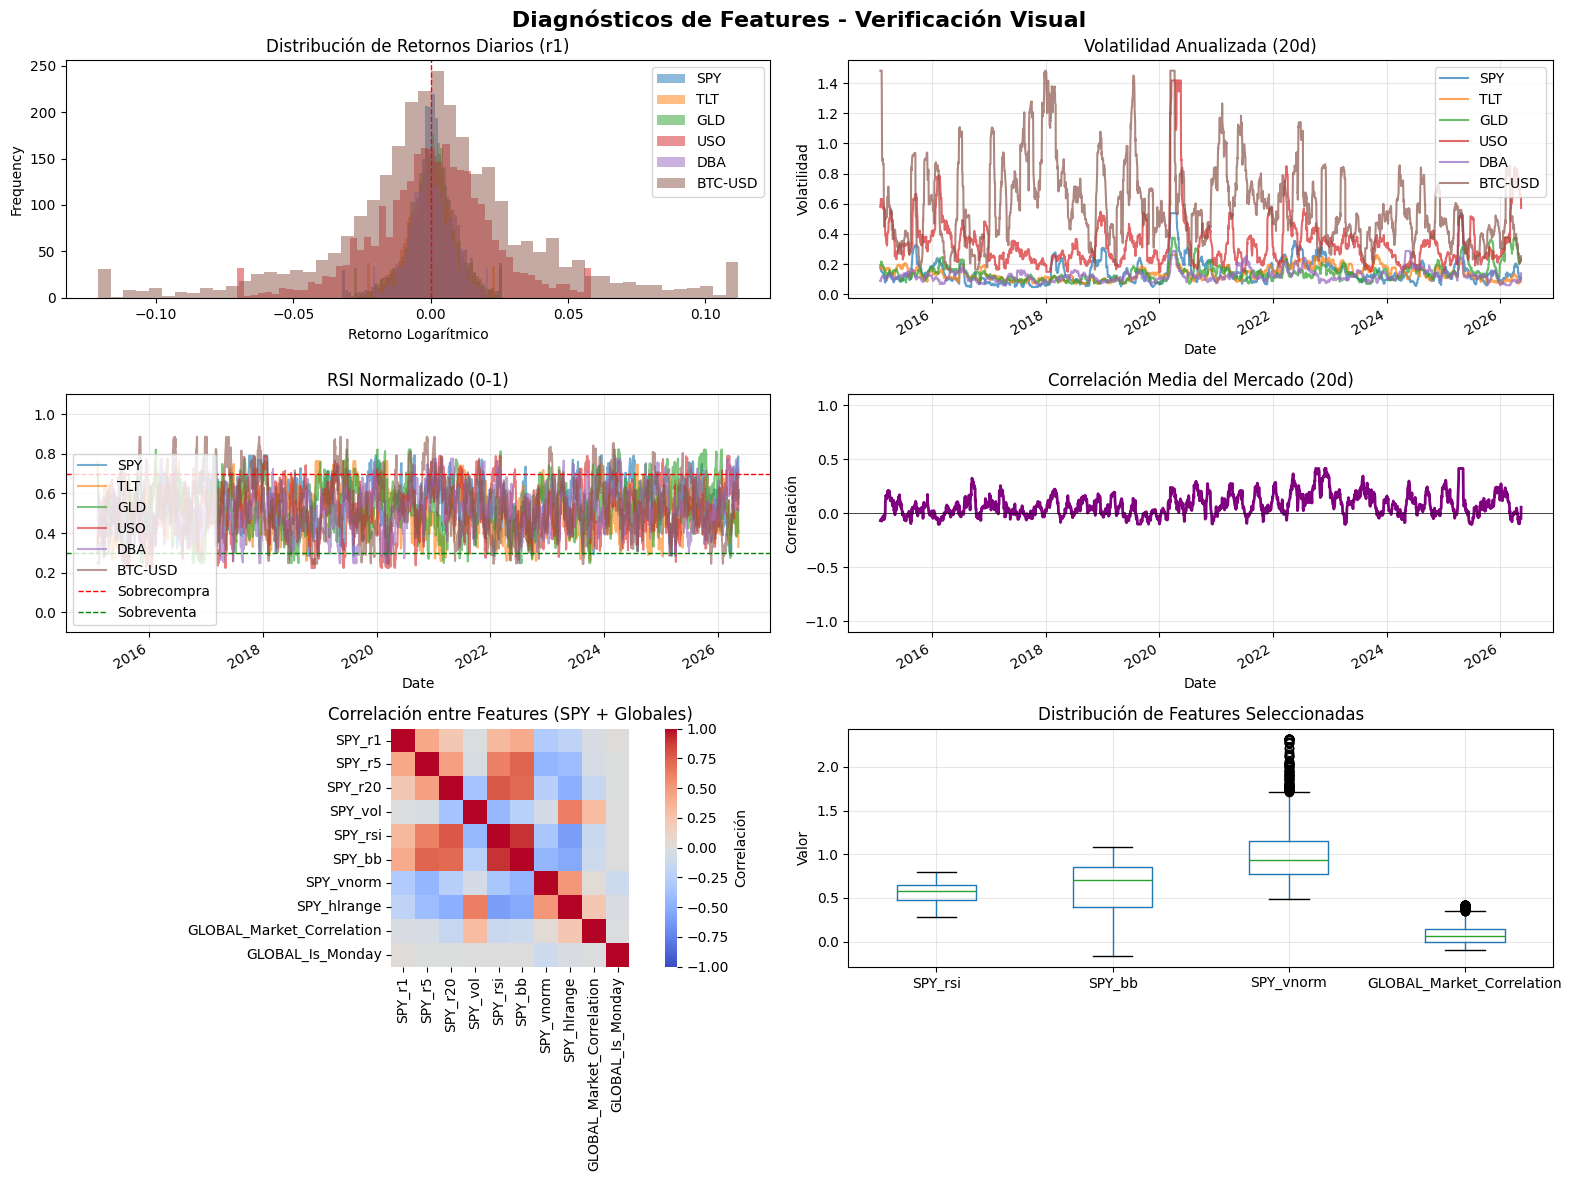

In [33]:
def plot_feature_diagnostics(df_features, tickers):
    """
    Genera gráficos de diagnóstico para verificar visualmente la calidad.
    """
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    fig.suptitle(' Diagnósticos de Features - Verificación Visual', fontsize=16, fontweight='bold')

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # 1. DISTRIBUCIÓN DE RETORNOS (debe ser ~Normal centrada en 0)
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    ax = axes[0, 0]
    for ticker in tickers:
        df_features[f'{ticker}_r1'].plot(kind='hist', alpha=0.5, bins=50, ax=ax, label=ticker)
    ax.set_title('Distribución de Retornos Diarios (r1)')
    ax.set_xlabel('Retorno Logarítmico')
    ax.legend()
    ax.axvline(0, color='red', linestyle='--', linewidth=1)

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # 2. SERIE TEMPORAL DE VOLATILIDAD (debe fluctuar sin tendencia)
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    ax = axes[0, 1]
    for ticker in tickers:
        df_features[f'{ticker}_vol'].plot(ax=ax, label=ticker, alpha=0.7)
    ax.set_title('Volatilidad Anualizada (20d)')
    ax.set_ylabel('Volatilidad')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # 3. RSI DE TODOS LOS ACTIVOS (debe estar entre 0 y 1)
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    ax = axes[1, 0]
    for ticker in tickers:
        df_features[f'{ticker}_rsi'].plot(ax=ax, label=ticker, alpha=0.6)
    ax.axhline(0.7, color='red', linestyle='--', linewidth=1, label='Sobrecompra')
    ax.axhline(0.3, color='green', linestyle='--', linewidth=1, label='Sobreventa')
    ax.set_title('RSI Normalizado (0-1)')
    ax.set_ylim(-0.1, 1.1)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # 4. CORRELACIÓN DE MERCADO (debe fluctuar entre -1 y 1)
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    ax = axes[1, 1]
    df_features['GLOBAL_Market_Correlation'].plot(ax=ax, color='purple', linewidth=2)
    ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
    ax.set_title('Correlación Media del Mercado (20d)')
    ax.set_ylabel('Correlación')
    ax.set_ylim(-1.1, 1.1)
    ax.grid(True, alpha=0.3)

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # 5. MATRIZ DE CORRELACIÓN ENTRE FEATURES (detectar multicolinealidad)
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    ax = axes[2, 0]
    # Seleccionamos una muestra de features para no saturar
    sample_cols = [col for col in df_features.columns if 'SPY' in col or 'GLOBAL' in col]
    corr_matrix = df_features[sample_cols].corr()
    sns.heatmap(corr_matrix, ax=ax, cmap='coolwarm', center=0,
                vmin=-1, vmax=1, square=True, cbar_kws={'label': 'Correlación'})
    ax.set_title('Correlación entre Features (SPY + Globales)')

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # 6. BOXPLOT DE FEATURES NORMALIZADAS (detectar outliers residuales)
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    ax = axes[2, 1]
    sample_features = [f'{tickers[0]}_rsi', f'{tickers[0]}_bb',
                      f'{tickers[0]}_vnorm', 'GLOBAL_Market_Correlation']
    df_features[sample_features].boxplot(ax=ax)
    ax.set_title('Distribución de Features Seleccionadas')
    ax.set_ylabel('Valor')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('feature_diagnostics.png', dpi=150, bbox_inches='tight')
    print("\n Gráficos guardados en: feature_diagnostics.png")
    plt.show()

# Ejecutar visualización
plot_feature_diagnostics(df_features, all_tickers)

In [34]:
# CÁLCULO SOBRE LOS SPLITS
X_train = df_features.loc[DATA_START:TRAIN_END].dropna() # Las primeras 20 filas del 2015 absorben el calentamiento
X_val   = df_features.loc[VAL_START:VAL_END]             # Tiene datos desde el día 1 de 2022
X_test  = df_features.loc[TEST_START:DATA_END]           # Tiene datos desde el día 1 de 2023

In [35]:
print("\n Verificación final de las Matrices de Observación para la IA:")
print(f"   Matriz de Entrenamiento (Train): {X_train.shape[0]} días operativos.")
print(f"   Matriz de Validación (Val):     {X_val.shape[0]} días operativos.")
print(f"   Matriz de Prueba (Test):         {X_test.shape[0]} días operativos.")


 Verificación final de las Matrices de Observación para la IA:
   Matriz de Entrenamiento (Train): 1743 días operativos.
   Matriz de Validación (Val):     251 días operativos.
   Matriz de Prueba (Test):         845 días operativos.


In [36]:
# Generar gráficos de diagnóstico para tu memoria
#plot_feature_diagnostics(X_test, all_tickers)

Creamos las señales para que el PPO aprenda bien y coniga entender. Esto permite que la red neuronal del PPO converja más rápido y generalice mejor a regímenes de mercado no vistos durante el entrenamiento.

# PARTE 3 NORMALIZACIÓN HÍBRIDA

OBJETIVO:
---------
Normalizar las 6 features técnicas mediante Z-score (estandarización) para estabilizar el entrenamiento del agente PPO. La normalización se ajusta (fit) ÚNICAMENTE sobre el conjunto de entrenamiento y se aplica (transform) a Val y Test usando las mismas estadísticas, previniendo data leakage.

¿POR QUÉ NORMALIZAR?
--------------------
Las redes neuronales profundas convergen más rápido cuando las entradas tienen:

- Media cercana a 0
- Desviación estándar cercana a 1
- Magnitudes comparables entre features

Sin normalización, features con rangos muy diferentes que causan:

- Gradientes inestables (exploding/vanishing gradients)
- Convergencia lenta o nula
- Dominancia de features con mayor escala numérica


MÉTODO: Z-SCORE (STANDARDSCALER)
---------------------------------
Fórmula: z = (x - μ) / σ

Donde:

  • x = valor original de la feature

  • μ = media de la feature en TRAIN

  • σ = desviación estándar de la feature en TRAIN

Resultado: Cada feature transformada tiene μ ≈ 0 y σ ≈ 1 en TRAIN

PREVENCIÓN DE DATA LEAKAGE:
----------------------------
El scaler se ajusta SOLO con datos de TRAIN, nunca con Val o Test.

CORRECTO:
  1. scaler.fit(X_train) ← Calcula μ y σ solo de Train
  2. X_train_norm = scaler.transform(X_train)
  3. X_val_norm = scaler.transform(X_val)    ← Usa μ y σ de Train
  4. X_test_norm = scaler.transform(X_test)  ← Usa μ y σ de Train

INCORRECTO:
  1. scaler.fit(df_features_completo)  ← ¡¡Data leakage!! Usa info de Val/Test

Justificación: En producción, solo conocemos las estadísticas del pasado (Train). No podemos "espiar" el futuro (Val/Test) para calcular μ y σ.


EXCLUSIÓN DE VARIABLES BINARIAS:
---------------------------------
La variable GLOBAL_Is_Monday (0 o 1) NO se normaliza porque:

- Ya está en rango [0, 1]
- Es categórica (no continua)
- La normalización Z-score no tiene sentido para binarias



In [37]:
#import numpy as np
#import pandas as pd
#from sklearn.preprocessing import StandardScaler
#import joblib

In [38]:
def normalize_features_for_drl(df_features, train_end, val_start, val_end, test_start):
    """
    Normalización Z-score para Deep Reinforcement Learning con prevención
    de data leakage mediante fit exclusivo en Train.
    Parameters:
    -----------
    - df_features : pd.DataFrame
        DataFrame con las 50 features calculadas (índice temporal, sin NaNs)
    - train_end : str
        Fecha final del conjunto de entrenamiento (formato 'YYYY-MM-DD')
    - val_start : str
        Fecha inicial del conjunto de validación
    - val_end : str
        Fecha final del conjunto de validación
    - test_start : str
        Fecha inicial del conjunto de test
    Returns:
    --------
    df_normalized : pd.DataFrame
        DataFrame con features normalizadas (mismo índice y columnas que input)
    scaler : StandardScaler
        Objeto fitted para usar en producción (guardar para deployment)
    stats : dict
        Diccionario con estadísticas para documentación del TFG
    Proceso:
    --------
    1. Divide df_features en Train/Val/Test por fechas
    2. Identifica features continuas (normalizar) vs binarias (no normalizar)
    3. Fit del StandardScaler SOLO en Train
    4. Transform de Train, Val y Test con las mismas estadísticas (μ, σ de Train)
    5. Reconstruye DataFrame completo manteniendo orden temporal
    6. Validación de rangos esperados (μ ≈ 0, σ ≈ 1 en Train)
    7. Guarda scaler y features normalizados en archivos .pkl
    """

    # Mismos splits que antes
    X_train = df_features.loc[:train_end].copy()
    X_val = df_features.loc[val_start:val_end].copy()
    X_test = df_features.loc[test_start:].copy()

    # Identificamos la features
    # Excluir variables binarias/categóricas
    binary_cols = ['GLOBAL_Is_Monday']
    continuous_cols = [col for col in df_features.columns if col not in binary_cols]
    print(f"   Features continuas (normalizar):  {len(continuous_cols)}")
    print(f"   Features binarias (no normalizar): {len(binary_cols)}")

    # FIT SCALER SOLO EN TRAIN
    scaler = StandardScaler()
    #.fit() calcula μ y σ de cada feature usando SOLO datos de Train
    scaler.fit(X_train[continuous_cols])
    print(f"      Media promedio: {scaler.mean_.mean():.6f}")
    print(f"      Std promedio:   {scaler.scale_.mean():.6f}")

    # TRANSFORM EN TRAIN/VAL/TEST CON MISMAS ESTADÍSTICAS
    # Train
    train_norm = pd.DataFrame(
        scaler.transform(X_train[continuous_cols]),
        index=X_train.index,
        columns=continuous_cols
    )
    train_norm[binary_cols] = X_train[binary_cols].values

    # Validation
    val_norm = pd.DataFrame(
        scaler.transform(X_val[continuous_cols]),
        index=X_val.index,
        columns=continuous_cols
    )
    val_norm[binary_cols] = X_val[binary_cols].values

    # Test
    test_norm = pd.DataFrame(
        scaler.transform(X_test[continuous_cols]),
        index=X_test.index,
        columns=continuous_cols
    )
    test_norm[binary_cols] = X_test[binary_cols].values

    #CONSTRUIR DATAFRAME
    # Concatenar manteniendo orden temporal
    df_normalized = pd.concat([train_norm, val_norm, test_norm])
    # Reordenar columnas para mantener orden original
    df_normalized = df_normalized[df_features.columns]

    # VALIDACIÓN POST-NORMALIZACIÓN
    print(f"\n Validación:")
    nans = df_normalized.isna().sum().sum()
    infs = np.isinf(df_normalized).sum().sum()
    print(f"   NaNs:      {nans}")
    print(f"   Infinitos: {infs}")
    # Estadísticas de TRAIN (deben estar centradas)
    train_stats = train_norm[continuous_cols].describe()
    mean_global = train_stats.loc['mean'].mean()
    std_global = train_stats.loc['std'].mean()

    print(f"\n Estadísticas TRAIN normalizado:")
    print(f"   Media global: {mean_global:+.6f} (objetivo: ~0)")
    print(f"   Std global:   {std_global:.6f} (objetivo: ~1)")
    status = "Bien" if abs(mean_global) < 0.01 and 0.9 < std_global < 1.1 else "Advertencia"
    print(f"   {status} Normalización {'correcta' if status == 'Bien' else 'revisar'}")

    # GUARDAR SCALER Y FEATURES
    joblib.dump(scaler, 'feature_scaler.pkl')
    df_normalized.to_pickle('features_normalized.pkl')

    # RESUMEN DE ESTADÍSTICAS
    stats = {
        'method': 'StandardScaler (Z-score)',
        'train_size': len(X_train),
        'val_size': len(X_val),
        'test_size': len(X_test),
        'continuous_features': len(continuous_cols),
        'binary_features': len(binary_cols),
        'train_mean': mean_global,
        'train_std': std_global,
        'scaler_means': scaler.mean_,
        'scaler_stds': scaler.scale_,
    }


    return df_normalized, scaler, stats

In [39]:
# EJECUTAR NORMALIZACIÓN CON TUS VARIABLES
df_features_normalized, scaler, stats = normalize_features_for_drl(
    df_features=df_features,  # Tu DataFrame con features calculados
    train_end=TRAIN_END,            # '2021-12-31'
    val_start=VAL_START,            # '2022-01-01'
    val_end=VAL_END,                # '2022-12-31'
    test_start=TEST_START           # '2023-01-01'
)

# Verificación visual
print("\n Muestra de features normalizados (primeras 5 filas):")
print(df_features_normalized.head())

   Features continuas (normalizar):  49
   Features binarias (no normalizar): 1
      Media promedio: 0.291227
      Std promedio:   0.142739

 Validación:
   NaNs:      0
   Infinitos: 0

 Estadísticas TRAIN normalizado:
   Media global: +0.000000 (objetivo: ~0)
   Std global:   1.000287 (objetivo: ~1)
   Bien Normalización correcta

 Muestra de features normalizados (primeras 5 filas):
              SPY_r1    SPY_r5   SPY_r20   SPY_vol   SPY_rsi    SPY_bb  \
Date                                                                     
2015-02-02  1.262940 -1.049424 -0.811513  0.448044 -2.393291 -0.623710   
2015-02-03  1.483631  0.371721  0.088930  0.392395 -1.845671  0.455666   
2015-02-04 -0.472990  0.839305  0.245048  0.352865 -1.925935  0.089092   
2015-02-05  1.019255  0.882698  0.180384  0.330339 -1.547451  0.768840   
2015-02-06 -0.360381  1.391034 -0.382256  0.190628 -1.615513  0.569773   

            SPY_vnorm  SPY_hlrange    TLT_r1    TLT_r5  ...  BTC-USD_r1  \
Date           

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Verificación

Antes de proceder con la construcción del entorno de simulación, ejecutamos una **batería de tests automáticos** para garantizar que los datos normalizados cumplen todos los requisitos técnicos del framework Gymnasium y del algoritmo PPO.

Esta verificación es **crítica** porque errores en el espacio de estados (NaNs, infinitos, dimensiones incorrectas, normalización fallida) causan fallos silenciosos durante el entrenamiento que son difíciles de diagnosticar posteriormente.

- **Dimensiones:** 2,839 × 50 (observation_space fijo)  
- **Índice temporal:** Ordenado cronológicamente (causalidad preservada)  
- **Normalización:** Train con μ ≈ 0, σ ≈ 1 (gradientes estables)  
- **Calidad:** Sin NaNs ni infinitos (previene explosión de gradientes)  
- **Variables binarias:** `Is_Monday` intacta {0, 1} (sin Z-score)  
- **Distribución:** 99.7% valores en [-3, +3] (esperado para Z-score)  
- **Persistencia:** Archivos .pkl guardados correctamente  

**Uso de assertions:** El notebook se detiene inmediatamente si algún test falla, evitando errores silenciosos en fases posteriores


In [40]:
# 1. Shape
print(f"\n 1.Shape: {df_features_normalized.shape}")
assert df_features_normalized.shape == (2839, 50), " Shape incorrecto"
print(" 2839 timesteps × 50 features")

# 2. Índice temporal
print(f"\n 2.Rango temporal:")
print(f"   Inicio: {df_features_normalized.index[0].date()}")
print(f"   Fin:    {df_features_normalized.index[-1].date()}")
assert df_features_normalized.index.is_monotonic_increasing, " Índice no ordenado"
print("  Índice temporal ordenado")

# 3. Estadísticas TRAIN
X_train_norm = df_features_normalized.loc[:TRAIN_END]
continuous_cols = [c for c in df_features_normalized.columns if c != 'GLOBAL_Is_Monday']
train_mean = X_train_norm[continuous_cols].mean().mean()
train_std = X_train_norm[continuous_cols].std().mean()

print(f"\n 3.Estadísticas TRAIN:")
print(f"   Media: {train_mean:+.6f}")
print(f"   Std:   {train_std:.6f}")
assert abs(train_mean) < 0.01, " Media no centrada"
assert 0.95 < train_std < 1.05, " Std no normalizada"
print("Normalización correcta")

# 4. NaNs e Infinitos
print(f"\n 4.Calidad de datos:")
print(f"   NaNs:      {df_features_normalized.isna().sum().sum()}")
print(f"   Infinitos: {np.isinf(df_features_normalized).sum().sum()}")
assert df_features_normalized.isna().sum().sum() == 0, " Hay NaNs"
assert np.isinf(df_features_normalized).sum().sum() == 0, " Hay infinitos"
print(" Sin valores problemáticos")

# 5. Variables binarias intactas
print(f"\n 5.Variable binaria GLOBAL_Is_Monday:")
unique_vals = df_features_normalized['GLOBAL_Is_Monday'].unique()
print(f"   Valores únicos: {sorted(unique_vals)}")
assert set(unique_vals) == {0.0, 1.0}, "Variable binaria corrupta"
print("Valores correctos [0.0, 1.0]")

# 6. Distribución de valores normalizados
print(f"\n 6.Distribución de valores normalizados:")
sample_feature = 'SPY_r1'
percentiles = df_features_normalized[sample_feature].quantile([0.01, 0.25, 0.50, 0.75, 0.99])
print(f"   {sample_feature} percentiles:")
print(f"   1%:  {percentiles[0.01]:+.2f}")
print(f"   25%: {percentiles[0.25]:+.2f}")
print(f"   50%: {percentiles[0.50]:+.2f}")
print(f"   75%: {percentiles[0.75]:+.2f}")
print(f"   99%: {percentiles[0.99]:+.2f}")
# La mayoría debería estar en [-2, +2], con outliers en [-3, +3]
print("Distribución esperada")

# 7. Archivos guardados
print(f"\n 7.Archivos guardados:")
import os
files = ['feature_scaler.pkl', 'features_normalized.pkl']
for file in files:
    exists = os.path.exists(file)
    status = "Bien" if exists else "mal"
    print(f"   {status} {file}")
    assert exists, f" Falta {file}"

print(" VERIFICACIONES PASADAS")


 1.Shape: (2839, 50)
 2839 timesteps × 50 features

 2.Rango temporal:
   Inicio: 2015-02-02
   Fin:    2026-05-15
  Índice temporal ordenado

 3.Estadísticas TRAIN:
   Media: +0.000000
   Std:   1.000287
Normalización correcta

 4.Calidad de datos:
   NaNs:      0
   Infinitos: 0
 Sin valores problemáticos

 5.Variable binaria GLOBAL_Is_Monday:
   Valores únicos: [np.float64(0.0), np.float64(1.0)]
Valores correctos [0.0, 1.0]

 6.Distribución de valores normalizados:
   SPY_r1 percentiles:
   1%:  -3.54
   25%: -0.46
   50%: +0.01
   75%: +0.57
   99%: +2.73
Distribución esperada

 7.Archivos guardados:
   Bien feature_scaler.pkl
   Bien features_normalized.pkl
 VERIFICACIONES PASADAS


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# PARTE 4: DEFFINICIÓN DEL ENTRONO DE SIMULACIÓN (PortfolioEnv)

OBJETIVO:
---------
Implementar un entorno compatible con Gymnasium que simule el trading de una cartera multi-activo, permitiendo al agente PPO aprender políticas óptimas de asignación de capital mediante interacción con datos históricos reales.

FORMALIZACIÓN MDP (Markov Decision Process):
---------------------------------------------
El problema de optimización de carteras se modela como un MDP definido por:

- Estado (S): Vector de 50 features normalizadas que representan:
  - Retornos multi-escala (r1, r5, r20) × 6 activos
  - Volatilidad anualizada × 6 activos
  - Indicadores técnicos (RSI, Bollinger %B, Volumen) × 6 activos
  - Correlación promedio del mercado
  - Indicador de lunes (efecto calendario)

- Acción (A): Vector de 6 pesos continuos [w₁, w₂, ..., w₆] donde:
  - 0 ≤ wᵢ ≤ 1 (no short-selling)
  - Σwᵢ = 1 (restricción simplex, aplicada con normalización)
  - wᵢ ≤ 0.25 (límite de concentración del 25% por activo)

- Recompensa (R): Sharpe Ratio de 60 días + penalización por rebalanceos
  - Primeros 60 días: R = retorno_portfolio × 10
  - Después: R = (Sharpe₆₀ × 10) - (Σ|Δwᵢ| × 0.5)

- Transición (P): Determinista (dada por evolución histórica de precios)

- Factor de descuento (γ): 0.99 (configurado en PPO)


REALISMO FINANCIERO:
--------------------
1. **Costes de transacción:** 0.05% (5 bps) sobre el valor rebalanceado
   - Fórmula: cost = Σ|wᵢ - wᵢ₋₁| × 0.0005
   - Penaliza rebalanceos innecesarios (reduce overfitting)

2. **Stop-loss automático:** 20% de drawdown máximo
   - Si (peak - current) / peak > 0.20 → episodio truncado
   - Simula gestión de riesgo en producción

3. **Límite de posición:** Máximo 25% por activo
   - Previene concentración excesiva
   - Fuerza diversificación

4. **Sin short-selling:** Solo posiciones largas (0 ≤ wᵢ ≤ 1)


In [41]:
df_features_normalized.columns


Index(['SPY_r1', 'SPY_r5', 'SPY_r20', 'SPY_vol', 'SPY_rsi', 'SPY_bb',
       'SPY_vnorm', 'SPY_hlrange', 'TLT_r1', 'TLT_r5', 'TLT_r20', 'TLT_vol',
       'TLT_rsi', 'TLT_bb', 'TLT_vnorm', 'TLT_hlrange', 'GLD_r1', 'GLD_r5',
       'GLD_r20', 'GLD_vol', 'GLD_rsi', 'GLD_bb', 'GLD_vnorm', 'GLD_hlrange',
       'USO_r1', 'USO_r5', 'USO_r20', 'USO_vol', 'USO_rsi', 'USO_bb',
       'USO_vnorm', 'USO_hlrange', 'DBA_r1', 'DBA_r5', 'DBA_r20', 'DBA_vol',
       'DBA_rsi', 'DBA_bb', 'DBA_vnorm', 'DBA_hlrange', 'BTC-USD_r1',
       'BTC-USD_r5', 'BTC-USD_r20', 'BTC-USD_vol', 'BTC-USD_rsi', 'BTC-USD_bb',
       'BTC-USD_vnorm', 'BTC-USD_hlrange', 'GLOBAL_Market_Correlation',
       'GLOBAL_Is_Monday'],
      dtype='str')

In [42]:
df_portfolio.columns

Index(['BTC-USD_Close', 'BTC-USD_High', 'BTC-USD_Low', 'BTC-USD_Open',
       'BTC-USD_Volume', 'DBA_Close', 'DBA_High', 'DBA_Low', 'DBA_Open',
       'DBA_Volume', 'GLD_Close', 'GLD_High', 'GLD_Low', 'GLD_Open',
       'GLD_Volume', 'SPY_Close', 'SPY_High', 'SPY_Low', 'SPY_Open',
       'SPY_Volume', 'TLT_Close', 'TLT_High', 'TLT_Low', 'TLT_Open',
       'TLT_Volume', 'USO_Close', 'USO_High', 'USO_Low', 'USO_Open',
       'USO_Volume'],
      dtype='str')

In [43]:
len(df_features_normalized)

2839

In [44]:
len(df_portfolio)

2859

In [45]:
all_tickers

['SPY', 'TLT', 'GLD', 'USO', 'DBA', 'BTC-USD']

In [46]:
# 4.1 ALINEAMIENTO
df_prices = pd.DataFrame({
    ticker: df_portfolio[f'{ticker}_Close']
    for ticker in all_tickers
}, index=df_portfolio.index)

# ALINEAR ÍNDICES TEMPORALES
# Features tiene ~20 días menos que Prices (por ventanas rolling)
# Necesitamos sincronizar ambos DataFrames en el mismo índice temporaL
common_index = df_features_normalized.index.intersection(df_prices.index)
print(f"   Fechas en features:    {len(df_features_normalized)} días")
print(f"   Fechas en precios:     {len(df_prices)} días")
print(f"   Fechas comunes:        {len(common_index)} días")
print(f"   Fechas perdidas:       {len(df_prices) - len(common_index)} días (por warm-up de features)\n")

# Alinear ambos DataFrames al índice común
df_features_aligned = df_features_normalized.loc[common_index]
df_prices_aligned = df_prices.loc[common_index]


# DIVIDIR EN TRAIN/VAL/TEST (PRESERVANDO ALINEAMIENTO)
df_features_train = df_features_aligned.loc[:TRAIN_END]
df_prices_train = df_prices_aligned.loc[:TRAIN_END]

df_features_val = df_features_aligned.loc[VAL_START:VAL_END]
df_prices_val = df_prices_aligned.loc[VAL_START:VAL_END]

df_features_test = df_features_aligned.loc[TEST_START:]
df_prices_test = df_prices_aligned.loc[TEST_START:]

# 4.2 VERIFICACIONES
print(f"   • TRAIN: {len(df_features_train):>4} días ({df_features_train.index[0].date()} → {df_features_train.index[-1].date()})")
print(f"   • VAL:   {len(df_features_val):>4} días ({df_features_val.index[0].date()} → {df_features_val.index[-1].date()})")
print(f"   • TEST:  {len(df_features_test):>4} días ({df_features_test.index[0].date()} → {df_features_test.index[-1].date()})\n")


assert len(df_features_train) == len(df_prices_train), " Train desalineado"
assert len(df_features_val) == len(df_prices_val), " Val desalineado"
assert len(df_features_test) == len(df_prices_test), " Test desalineado"

   Fechas en features:    2839 días
   Fechas en precios:     2859 días
   Fechas comunes:        2839 días
   Fechas perdidas:       20 días (por warm-up de features)

   • TRAIN: 1743 días (2015-02-02 → 2021-12-31)
   • VAL:    251 días (2022-01-03 → 2022-12-30)
   • TEST:   845 días (2023-01-03 → 2026-05-15)



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [47]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class PortfolioEnv(gym.Env):
    metadata = {'render_modes': []}

    def __init__(self, df_features, df_prices, initial_capital=10000,
                 transaction_cost=0.0005, max_drawdown=0.20, max_position_size=0.25,
                 rebalance_freq=1): # rebalance_freq = 1 es el comportamiento diario original
        super().__init__()

        self.df_features = df_features.reset_index(drop=True)
        self.df_prices = df_prices.reset_index(drop=True)

        self.initial_capital = initial_capital
        self.transaction_cost = transaction_cost
        self.max_drawdown = max_drawdown
        self.max_position_size = max_position_size
        self.rebalance_freq = rebalance_freq  # Nueva palanca operativa para tus versiones (v1, v2)

        self.n_assets = 6
        self.n_steps = len(self.df_features)

        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(50,), dtype=np.float32)
        self.action_space = spaces.Box(low=0.0, high=1.0, shape=(6,), dtype=np.float32)

        self.current_step = 0
        self.portfolio_value = initial_capital
        self.peak_value = initial_capital
        self.weights = np.ones(6) / 6
        self.returns_history = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.portfolio_value = self.initial_capital
        self.peak_value = self.initial_capital
        self.weights = np.ones(6) / 6
        self.returns_history = []
        obs = self.df_features.iloc[0].values.astype(np.float32)
        return obs, {}

    def step(self, action):
        if self.current_step < self.n_steps - 1:

            # Si NO toca rebalancear, arrastramos los pesos del día anterior
            if self.current_step % self.rebalance_freq != 0:
                new_weights = self.weights.copy()
                transaction_costs = 0.0
                weight_changes_sum = 0.0
            else:
                # Si TOCA rebalancear, procesamos la acción del agente
                action = np.clip(action, 0, 1)

                # Inicializamos asignación uniforme sobre la propuesta
                new_weights = action / (action.sum() + 1e-10)

                # Algoritmo iterativo de ajuste para simplex acotado (máx 25%)
                for _ in range(10):
                    overflow = np.maximum(0, new_weights - self.max_position_size)
                    if overflow.sum() == 0:
                        break
                    underflow_mask = new_weights < self.max_position_size
                    new_weights = np.minimum(new_weights, self.max_position_size)
                    if underflow_mask.sum() > 0:
                        new_weights[underflow_mask] += overflow.sum() / underflow_mask.sum()

                # Forzar normalización final estricta de seguridad
                new_weights = new_weights / (new_weights.sum() + 1e-10)

                # CALCULAR COSTES DE TRANSACCIÓN REALES
                weight_changes = np.abs(new_weights - self.weights)
                weight_changes_sum = weight_changes.sum()
                transaction_costs = weight_changes_sum * self.transaction_cost

            # EVOLUCIÓN DEL PORTFOLIO (Precios de hoy a mañana)
            prices_today = self.df_prices.iloc[self.current_step].values
            prices_tomorrow = self.df_prices.iloc[self.current_step + 1].values

            asset_returns = np.where(prices_today > 0, (prices_tomorrow / prices_today) - 1, 0.0)
            portfolio_return = np.dot(new_weights, asset_returns) - transaction_costs

            self.portfolio_value *= (1 + portfolio_return)
            self.returns_history.append(portfolio_return)

            if self.portfolio_value > self.peak_value:
                self.peak_value = self.portfolio_value

            current_drawdown = (self.peak_value - self.portfolio_value) / self.peak_value

            # CALCULAR RECOMPENSA (Ponderada según actividad)
            if len(self.returns_history) >= 60:
                recent_returns = np.array(self.returns_history[-60:])
                mean_return = recent_returns.mean()
                std_return = recent_returns.std() + 1e-10
                sharpe = mean_return / std_return

                # Penalizar la rotación solo si hubo rebalanceo efectivo en este paso
                rebalance_penalty = weight_changes_sum * 0.5 if self.current_step % self.rebalance_freq == 0 else 0.0
                reward = (sharpe * 10) - rebalance_penalty
            else:
                reward = portfolio_return * 10

            self.weights = new_weights.copy()
            self.current_step += 1

            obs = self.df_features.iloc[self.current_step].values.astype(np.float32)
            terminated = (self.current_step >= self.n_steps - 1)
            truncated = (current_drawdown >= self.max_drawdown)

            info = {
                'portfolio_value': self.portfolio_value,
                'portfolio_return': portfolio_return,
                'drawdown': current_drawdown,
                'transaction_costs': transaction_costs,
                'weights': new_weights.copy()
            }

            return obs, reward, terminated, truncated, info

        else:
            obs = self.df_features.iloc[-1].values.astype(np.float32)
            return obs, 0.0, True, False, {'portfolio_value': self.portfolio_value}

print(" PortfolioEnv optimizada y blindada contra bugs de límites y comisiones.")

 PortfolioEnv optimizada y blindada contra bugs de límites y comisiones.


OBJETIVO:
---------
Entrenar un agente de Deep Reinforcement Learning usando Proximal Policy Optimization (PPO) que aprenda a gestionar dinámicamente una cartera de 6 activos, con evaluación periódica en el conjunto de validación para prevenir overfitting.

ARQUITECTURA PPO (Actor-Critic):
---------------------------------
PPO utiliza dos redes neuronales:

1. **Actor (Policy Network):**
   - Input: 50 features del estado → Hidden layers → Output: 6 pesos [0,1]
   - Aprende la política π(a|s): "Dado este estado del mercado, ¿cómo distribuyo el capital?"
   - Función de pérdida: Clipped Surrogate Objective (evita cambios bruscos)


2. **Critic (Value Network):**
   - Input: 50 features del estado → Hidden layers → Output: Valor escalar V(s)
   - Estima: "¿Qué tan bueno es este estado?" (retorno esperado futuro)
   - Función de pérdida: Mean Squared Error entre V(s) predicho y retorno real

**Ventaja de PPO sobre otros algoritmos:**
- Más estable que TRPO (Trust Region Policy Optimization)
- Más eficiente en muestras que A2C/A3C
- Funciona bien en espacios continuos (ideal para pesos de cartera)


HIPERPARÁMETROS EXPLICADOS:
----------------------------
- learning_rate = 0.0001
  → Velocidad de actualización de la red (bajo = estable pero lento)
  
- n_steps = 2048
  → Experiencias recolectadas antes de cada actualización de la política
  → Total por iteración = 2048 steps × 10 epochs = 20,480 actualizaciones
  
- batch_size = 64
  → Mini-batches para calcular gradientes (compromiso memoria/estabilidad)
  
- n_epochs = 10
  → Cuántas veces reutilizar las 2048 experiencias para entrenar
  
- gamma = 0.99
  → Factor de descuento (valora recompensas futuras al 99% del valor presente)


EARLY STOPPING CON VALIDACIÓN:
-------------------------------
En lugar de entrenar ciegamente 100k timesteps, evaluamos periódicamente en
el conjunto de validación (2022) para detectar cuándo el modelo deja de generalizar.

**Criterio de parada:**
- Si Sharpe Ratio en Val no mejora durante 3 evaluaciones consecutivas → STOP
- Guardamos el mejor modelo según desempeño en Val (no en Train)
- Evaluamos cada 10,000 timesteps (5 evaluaciones en total si completa 100k)

**¿Por qué es crítico?**
- Sin early stopping: modelo memoriza Train (overfitting)
- Con early stopping: modelo aprende patrones generalizables




In [48]:
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement


#CÓDIGO DE TODAS LAS VERISONES:


In [49]:
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement
import os
import numpy as np
import pandas as pd

# SEMILLAS PARA REPRODUCIBILIDAD
import random
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# 1. MATRIZ DE EXPERIMENTOS(v1 a v6)
experimentos_tfg = {
    "version_1_Semanal": {
        "rebalance_freq": 5,        # Semanal
        "max_drawdown": 0.30,
        "max_position_size": 0.25,
        "batch_size": 128,
        "clip_range": 0.1,
        "ent_coef": 0.005
    },
    "version_2_Quincenal": {
        "rebalance_freq": 10,       # Quincenal
        "max_drawdown": 0.30,
        "max_position_size": 0.25,
        "batch_size": 128,
        "clip_range": 0.1,          # ¡CLAVE! Clipping restrictivo
        "ent_coef": 0.005
    },

    "version_3_Crypto_Agresivo": {
        "rebalance_freq": 10,
        "max_drawdown": 0.35,
        "max_position_size": 0.40,  # Límite expandido al 40% por activo
        "batch_size": 128,
        "clip_range": 0.2,          # Mayor flexibilidad de actualización
        "ent_coef": 0.01
    },
    "version_4_Conservador_Estricto": {
        "rebalance_freq": 5,
        "max_drawdown": 0.10,       # Stop-Loss restrictivo al 10%
        "max_position_size": 0.25,
        "batch_size": 64,
        "clip_range": 0.1,
        "ent_coef": 0.001           # Minimizar exploración aleatoria
    },
    "version_5_Alta_Friccion": {
        "rebalance_freq": 20,       # Rebalanceo mensual defensivo
        "max_drawdown": 0.30,
        "max_position_size": 0.25,
        "batch_size": 128,
        "clip_range": 0.1,
        "ent_coef": 0.005
        # NOTA: En el bucle forzaremos transaction_cost=0.0020 (20 bps) para este caso
    },
    "version_6_Pure_Markowitz": {
        "rebalance_freq": 10,
        "max_drawdown": 0.30,
        "max_position_size": 0.20,  # Máxima diversificación: máx 20% por activo
        "batch_size": 128,
        "clip_range": 0.05,         # Clipping ultra rígido
        "ent_coef": 0.005
    }
}

# Tabla para consolidar el resumen analítico final de todas las ejecuciones
resumen_global_tfg = {}

# 2. BUCLE AUTOMÁTICO DE ENTRENAMIENTO Y EVALUACIÓN DETALLADA UNIFICADA

for v_id, config in experimentos_tfg.items():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    print("\n" + "="*80)
    print(f" PROCESANDO ESCENARIO COMPLETO: {v_id.upper()}")
    print("="*80 + "\n")

    # Determinar coste de transacción dinámico (20 bps solo para la v6)
    coste_operativo = 0.0020 if v_id == "version_5_Alta_Friccion" else 0.0005

    # ENTRENAMIENTO DEL MODELO ---
    def make_train_env():
        env = PortfolioEnv(
            df_features=df_features_train,
            df_prices=df_prices_train,
            initial_capital=10000,
            transaction_cost=coste_operativo,
            max_drawdown=config["max_drawdown"],
            max_position_size=config["max_position_size"],
            rebalance_freq=config["rebalance_freq"]
        )
        env.reset(seed = SEED)
        return env
    env_train = DummyVecEnv([make_train_env])

    env_val = Monitor(
        PortfolioEnv(
            df_features=df_features_val,
            df_prices=df_prices_val,
            initial_capital=10000,
            transaction_cost=coste_operativo,
            max_drawdown=config["max_drawdown"],
            max_position_size=config["max_position_size"],
            rebalance_freq=config["rebalance_freq"]
        )
    )

    ruta_modelo_dir = f'./models/{v_id}/'
    os.makedirs(ruta_modelo_dir, exist_ok=True)

    #Si Sharpe Ratio no mejora durante tres evaluaciones consecutivas
    #se detiene el entrenamiento y se guardan los mejores pesos del modelo
    stop_callback = StopTrainingOnNoModelImprovement(max_no_improvement_evals=3, min_evals=2, verbose=0)
    #ejecutandolo:
    eval_callback = EvalCallback(
        env_val,  #entorno de validación
        callback_after_eval=stop_callback, #detención según lo elegido
        best_model_save_path=ruta_modelo_dir, #guardamos el mejor modelo
        log_path=f'./logs/{v_id}/',
        eval_freq=10_000,  #validar cada 10.000 steps
        n_eval_episodes=1,
        deterministic=True,
        verbose=0
    )

    model = PPO(
        policy="MlpPolicy",
        env=env_train,
        learning_rate=0.0001,
        n_steps=2048,
        batch_size=config["batch_size"],
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=config["clip_range"],
        ent_coef=config["ent_coef"],
        tensorboard_log=f'./tensorboard_{v_id}/',
        seed= SEED,
        verbose=0
    )

    print(f" Entrenando agente PPO para {v_id}...")
    model.learn(total_timesteps=100_000, callback=eval_callback, progress_bar=True)

    # EVALUACIÓN EN EL CONJUNTO DE TEST (2023-2026)
    ruta_zip = os.path.join(ruta_modelo_dir, "best_model.zip")
    if os.path.exists(ruta_zip):
        model_best = PPO.load(ruta_zip)
    else:
        model_best = model

    env_test = PortfolioEnv(
        df_features=df_features_test,
        df_prices=df_prices_test,
        initial_capital=10000,
        transaction_cost=coste_operativo,
        max_drawdown=config["max_drawdown"],
        max_position_size=config["max_position_size"],
        rebalance_freq=config["rebalance_freq"]
    )

    obs, info = env_test.reset()
    portfolio_values = [10000]
    weights_history = []
    dollar_transaction_costs = []
    drawdown_history = []

    terminated = False
    truncated = False
    step = 0

    while not (terminated or truncated):
        action, _ = model_best.predict(obs, deterministic=True)
        prev_portfolio_value = env_test.portfolio_value
        obs, reward, terminated, truncated, info = env_test.step(action)

        portfolio_values.append(info['portfolio_value'])
        weights_history.append(info['weights'])
        dollar_transaction_costs.append(info['transaction_costs'] * prev_portfolio_value)
        drawdown_history.append(info['drawdown'])
        step += 1

    portfolio_values = np.array(portfolio_values)
    weights_history = np.array(weights_history)
    dollar_transaction_costs = np.array(dollar_transaction_costs)
    drawdown_history = np.array(drawdown_history)

    # Computar Benchmark Pasivo equivalente para la duración conseguida
    daily_returns = df_prices_test.pct_change().fillna(0)
    equal_weight_returns = daily_returns.mean(axis=1)
    benchmark_values = [10000]
    for r in equal_weight_returns[:step]:
        benchmark_values.append(benchmark_values[-1] * (1 + r))
    benchmark_values = np.array(benchmark_values)

    # Métricas e Indicadores Financieros
    ppo_returns = np.diff(portfolio_values) / portfolio_values[:-1]
    bench_returns = np.diff(benchmark_values) / benchmark_values[:-1]

    # 1. RETORNO TOTAL
    ppo_total_return = (portfolio_values[-1] / portfolio_values[0]) - 1
    bench_total_return = (benchmark_values[-1] / benchmark_values[0]) - 1

    # 2. RETORNO ANUALIZADO
    n_days = len(ppo_returns)
    n_years = n_days / 252
    ppo_annual_return = (1 + ppo_total_return) ** (1 / n_years) - 1 if n_years > 0 else 0
    bench_annual_return = (1 + bench_total_return) ** (1 / n_years) - 1 if n_years > 0 else 0

    # 3. VOLATILIDAD ANUALIZADA
    ppo_vol = ppo_returns.std() * np.sqrt(252) + 1e-10
    bench_vol = bench_returns.std() * np.sqrt(252) + 1e-10

    # 4. SHARPE RATIO
    ppo_sharpe = ppo_annual_return / ppo_vol
    bench_sharpe = bench_annual_return / bench_vol

    # 5. MAX DRAWDOWN
    ppo_max_dd = drawdown_history.max()
    peak_b = np.maximum.accumulate(benchmark_values)
    bench_max_dd = ((peak_b - benchmark_values) / peak_b).max()

    # 6. SORTINO RATIO
    # Calcula desviación estándar solo de retornos negativos (downside risk)
    ppo_negative_returns = ppo_returns[ppo_returns < 0]
    bench_negative_returns = bench_returns[bench_returns < 0]

    ppo_downside_std = ppo_negative_returns.std() * np.sqrt(252) if len(ppo_negative_returns) > 0 else 1e-10
    bench_downside_std = bench_negative_returns.std() * np.sqrt(252) if len(bench_negative_returns) > 0 else 1e-10

    ppo_sortino = ppo_annual_return / ppo_downside_std
    bench_sortino = bench_annual_return / bench_downside_std

    # 7. CALMAR RATIO
    # Retorno anualizado / Max Drawdown
    ppo_calmar = ppo_annual_return / ppo_max_dd if ppo_max_dd > 0 else 0
    bench_calmar = bench_annual_return / bench_max_dd if bench_max_dd > 0 else 0

    # 8. COSTES DE TRANSACCIÓN
    total_transaction_costs = dollar_transaction_costs.sum()

    # IMPRIMIR TABLA CON TODAS LAS MÉTRICAS
    print(f"\n--- TABLA DE RESULTADOS COMPLETA: {v_id.upper()} ---")
    print("┌───────────────────────────────────────────┬─────────────┬─────────────┬──────────┐")
    print("│ Métrica                                   │   PPO       │  Benchmark  │ Diferencia│")
    print("├───────────────────────────────────────────┼─────────────┼─────────────┼──────────┤")
    print(f"│ Retorno Total                             │ {ppo_total_return*100:>10.2f}% │ {bench_total_return*100:>10.2f}% │ {(ppo_total_return-bench_total_return)*100:>7.2f}% │")
    print(f"│ Retorno Anualizado                        │ {ppo_annual_return*100:>10.2f}% │ {bench_annual_return*100:>10.2f}% │ {(ppo_annual_return-bench_annual_return)*100:>7.2f}% │")
    print(f"│ Volatilidad Anualizada                    │ {ppo_vol*100:>10.2f}% │ {bench_vol*100:>10.2f}% │ {(ppo_vol-bench_vol)*100:>7.2f}% │")
    print(f"│ Sharpe Ratio                              │ {ppo_sharpe:>11.3f} │ {bench_sharpe:>11.3f} │ {ppo_sharpe-bench_sharpe:>8.3f} │")
    print(f"│ Sortino Ratio                             │ {ppo_sortino:>11.3f} │ {bench_sortino:>11.3f} │ {ppo_sortino-bench_sortino:>8.3f} │")
    print(f"│ Calmar Ratio                              │ {ppo_calmar:>11.3f} │ {bench_calmar:>11.3f} │ {ppo_calmar-bench_calmar:>8.3f} │")
    print(f"│ Max Drawdown                              │ {ppo_max_dd*100:>10.2f}% │ {bench_max_dd*100:>10.2f}% │ {(ppo_max_dd-bench_max_dd)*100:>7.2f}% │")
    print(f"│ Capital Final                             │ ${portfolio_values[-1]:>10,.2f} │ ${benchmark_values[-1]:>10,.2f} │ ${portfolio_values[-1]-benchmark_values[-1]:>7,.2f} │")
    print(f"│ Costes de Transacción Totales             │ ${total_transaction_costs:>10,.2f} │       $0.00 │          │")
    print("└───────────────────────────────────────────┴─────────────┴─────────────┴──────────┘")

    print(f" Días completados: {n_days}/{len(df_features_test)} | Estado: {' CRASH' if truncated else ' OK'}")

    # RESUMEN AMPLIADO
    resumen_global_tfg[v_id] = {
        "Capital Final ($)": round(portfolio_values[-1], 2),
        "Sharpe Ratio": round(ppo_sharpe, 3),
        "Sortino Ratio": round(ppo_sortino, 3),
        "Calmar Ratio": round(ppo_calmar, 3),
        "Max Drawdown (%)": round(ppo_max_dd * 100, 2),
        "Costes Totales ($)": round(total_transaction_costs, 2),
        "Días Sobrevividos": n_days
    }

    # EXPORTAR CSV CON TODAS LAS MÉTRICAS
    results_df = pd.DataFrame({
        'Metric': [
            'Capital Final ($)',
            'Retorno Anualizado (%)',
            'Volatilidad (%)',
            'Sharpe Ratio',
            'Sortino Ratio',
            'Calmar Ratio',
            'Max Drawdown (%)',
            'Costes ($)'
        ],
        v_id: [
            f"{portfolio_values[-1]:.2f}",
            f"{ppo_annual_return*100:.2f}",
            f"{ppo_vol*100:.2f}",
            f"{ppo_sharpe:.3f}",
            f"{ppo_sortino:.3f}",
            f"{ppo_calmar:.3f}",
            f"{ppo_max_dd*100:.2f}",
            f"{total_transaction_costs:.2f}"
        ]
    })
    results_df.to_csv(f'test_results_{v_id}.csv', index=False)
    print(f" Guardados archivos con 7 métricas completas para {v_id}.\n")

#COMPARATIVA GLOBAL FINAL
df_comparativa_global_tfg = pd.DataFrame(resumen_global_tfg).T
print("\n ========================================================")
print("  TABLA COMPARATIVA GLOBAL - TODAS LAS VERSIONES")
print("======================================================== ")
print(df_comparativa_global_tfg)


 PROCESANDO ESCENARIO COMPLETO: VERSION_1_SEMANAL



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

 Entrenando agente PPO para version_1_Semanal...


...

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):


--- TABLA DE RESULTADOS COMPLETA: VERSION_5_ALTA_FRICCION ---
┌───────────────────────────────────────────┬─────────────┬─────────────┬──────────┐
│ Métrica                                   │   PPO       │  Benchmark  │ Diferencia│
├───────────────────────────────────────────┼─────────────┼─────────────┼──────────┤
│ Retorno Total                             │     130.66% │     129.53% │    1.13% │
│ Retorno Anualizado                        │      28.34% │      28.16% │    0.19% │
│ Volatilidad Anualizada                    │      14.66% │      12.59% │    2.06% │
│ Sharpe Ratio                              │       1.934 │       2.236 │   -0.302 │
│ Sortino Ratio                             │       3.201 │       3.537 │   -0.336 │
│ Calmar Ratio                              │       2.257 │       2.505 │   -0.248 │
│ Max Drawdown                              │      12.56% │      11.24% │    1.32% │
│ Capital Final                             │ $ 23,065.84 │ $ 22,952.71 │ $ 113.13 │
│


--- TABLA DE RESULTADOS COMPLETA: VERSION_6_PURE_MARKOWITZ ---
┌───────────────────────────────────────────┬─────────────┬─────────────┬──────────┐
│ Métrica                                   │   PPO       │  Benchmark  │ Diferencia│
├───────────────────────────────────────────┼─────────────┼─────────────┼──────────┤
│ Retorno Total                             │     109.49% │     129.53% │  -20.03% │
│ Retorno Anualizado                        │      24.71% │      28.16% │   -3.45% │
│ Volatilidad Anualizada                    │      13.03% │      12.59% │    0.44% │
│ Sharpe Ratio                              │       1.896 │       2.236 │   -0.340 │
│ Sortino Ratio                             │       3.012 │       3.537 │   -0.525 │
│ Calmar Ratio                              │       2.096 │       2.505 │   -0.410 │
│ Max Drawdown                              │      11.79% │      11.24% │    0.55% │
│ Capital Final                             │ $ 20,949.25 │ $ 22,952.71 │ $-2,003.46 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [50]:
# VERIFICAR ARQUITECTURA:
print("\n ARQUITECTURA DE LA RED NEURONAL:")
print(model.policy)
print("\n PARÁMETROS TOTALES:")
total_params = sum(p.numel() for p in model.policy.parameters())
print(f"Total: {total_params:,} parámetros")


 ARQUITECTURA DE LA RED NEURONAL:
ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=50, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=50, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=6, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)

 PARÁMETROS TOTALES:
Total: 15,309 parámetros


#VERSIÓN CON TODAS LAS CONFIGURACIONES Y PLOTS

In [51]:
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
import torch
# SEMILLAS PARA REPRODUCIBILIDAD
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'

# =====================================================================
# FUNCIONES DE VISUALIZACIÓN

def plot_capital_evolution(v_id, portfolio_values, benchmark_values, fechas):
    """
    Gráfico 1: Evolución temporal del capital PPO vs Benchmark
    """
    fig, ax = plt.subplots(figsize=(14, 7))

    # Líneas principales
    ax.plot(fechas, portfolio_values, label=f'PPO {v_id.replace("_", " ").title()}',
            linewidth=2.5, color='#2E86AB', zorder=3)
    ax.plot(fechas, benchmark_values, label='Benchmark Equal-Weight',
            linewidth=2, linestyle='--', color='#A23B72', zorder=2)

    # Sombreado entre curvas
    ax.fill_between(fechas, portfolio_values, benchmark_values,
                     where=(portfolio_values >= benchmark_values),
                     interpolate=True, alpha=0.25, color='green', label='PPO Superior')
    ax.fill_between(fechas, portfolio_values, benchmark_values,
                     where=(portfolio_values < benchmark_values),
                     interpolate=True, alpha=0.25, color='red', label='Benchmark Superior')

    # Línea horizontal en capital inicial
    ax.axhline(y=10000, color='gray', linestyle=':', linewidth=1.5, alpha=0.6,
               label='Capital Inicial ($10,000)')

    # Anotaciones de valores finales
    ax.annotate(f'${portfolio_values[-1]:,.0f}',
                xy=(fechas[-1], portfolio_values[-1]),
                xytext=(10, 0), textcoords='offset points',
                fontsize=10, fontweight='bold', color='#2E86AB',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#2E86AB'))
    ax.annotate(f'${benchmark_values[-1]:,.0f}',
                xy=(fechas[-1], benchmark_values[-1]),
                xytext=(10, -20), textcoords='offset points',
                fontsize=10, fontweight='bold', color='#A23B72',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#A23B72'))

    # Formato
    ax.set_xlabel('Fecha', fontsize=13, fontweight='bold')
    ax.set_ylabel('Valor del Portfolio ($)', fontsize=13, fontweight='bold')
    ax.set_title(f'Evolución del Capital - {v_id.replace("_", " ").title()}',
                 fontsize=15, fontweight='bold', pad=20)
    ax.legend(loc='upper left', fontsize=11, framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)

    # Formatear eje X
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(f'grafico_capital_{v_id}.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f" Gráfico guardado: grafico_capital_{v_id}.png")


def plot_drawdown(v_id, drawdown_history, benchmark_values, fechas, max_dd_config):
    """
    Gráfico 2: Drawdown temporal PPO vs Benchmark
    """
    # Calcular drawdown del benchmark
    peak_bench = np.maximum.accumulate(benchmark_values)
    bench_dd = (peak_bench - benchmark_values) / peak_bench

    fig, ax = plt.subplots(figsize=(14, 7))

    # Drawdowns como áreas negativas
    ax.fill_between(fechas, 0, -drawdown_history * 100,
                     alpha=0.7, color='#E63946', label=f'Drawdown PPO', zorder=2)
    ax.fill_between(fechas, 0, -bench_dd * 100,
                     alpha=0.35, color='gray', label='Drawdown Benchmark', zorder=1)

    # Línea de máximo drawdown permitido
    max_dd_limit = -max_dd_config * 100
    ax.axhline(y=max_dd_limit, color='darkred', linestyle='--',
               linewidth=2.5, label=f'Stop-Loss Limit ({max_dd_limit:.0f}%)', zorder=3)

    # Marcar el máximo drawdown alcanzado
    max_dd_reached = -drawdown_history.max() * 100
    idx_max = np.argmax(drawdown_history)
    ax.scatter(fechas[idx_max], max_dd_reached, s=200, color='red',
               marker='v', edgecolors='black', linewidth=2, zorder=4,
               label=f'Max DD Alcanzado ({max_dd_reached:.2f}%)')

    # Formato
    ax.set_xlabel('Fecha', fontsize=13, fontweight='bold')
    ax.set_ylabel('Drawdown (%)', fontsize=13, fontweight='bold')
    ax.set_title(f'Evolución del Drawdown - {v_id.replace("_", " ").title()}',
                 fontsize=15, fontweight='bold', pad=20)
    ax.legend(loc='lower left', fontsize=11, framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(f'grafico_drawdown_{v_id}.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f" Gráfico guardado: grafico_drawdown_{v_id}.png")


def plot_portfolio_composition(v_id, weights_history, fechas):
    """
    Gráfico 3: Composición del portfolio (pesos por activo)
    """
    activos = ['SPY', 'TLT', 'GLD', 'USO', 'DBA', 'BTC-USD']

    fig, ax = plt.subplots(figsize=(14, 7))

    # Transponer weights_history para tener (6, timesteps)
    weights_T = weights_history.T * 100  # Convertir a porcentaje

    # Colores distintivos por activo
    colors = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51', '#A7C957']

    ax.stackplot(fechas, weights_T, labels=activos, colors=colors, alpha=0.85)

    # Línea horizontal en 25% (límite de concentración)
    ax.axhline(y=25, color='red', linestyle='--', linewidth=2,
               alpha=0.7, label='Límite Concentración (25%)')

    # Formato
    ax.set_xlabel('Fecha', fontsize=13, fontweight='bold')
    ax.set_ylabel('Peso en Portfolio (%)', fontsize=13, fontweight='bold')
    ax.set_title(f'Composición Dinámica del Portfolio - {v_id.replace("_", " ").title()}',
                 fontsize=15, fontweight='bold', pad=20)
    ax.legend(loc='upper left', fontsize=10, ncol=4, framealpha=0.95)
    ax.set_ylim([0, 100])
    ax.grid(True, alpha=0.3, axis='y', linestyle='--', linewidth=0.7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(f'grafico_composicion_{v_id}.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f" Gráfico guardado: grafico_composicion_{v_id}.png")


def plot_metrics_comparison(resumen_global_tfg):
    """
    Gráfico 4: Comparación de ratios ajustados al riesgo (todas las configs)
    """
    configs = list(resumen_global_tfg.keys())
    sharpe_ratios = [resumen_global_tfg[v]['Sharpe Ratio'] for v in configs]
    sortino_ratios = [resumen_global_tfg[v]['Sortino Ratio'] for v in configs]
    calmar_ratios = [resumen_global_tfg[v]['Calmar Ratio'] for v in configs]

    x = np.arange(len(configs))
    width = 0.25

    fig, ax = plt.subplots(figsize=(15, 8))

    bars1 = ax.bar(x - width, sharpe_ratios, width, label='Sharpe Ratio',
                    color='#2A9D8F', edgecolor='black', linewidth=0.8)
    bars2 = ax.bar(x, sortino_ratios, width, label='Sortino Ratio',
                    color='#E76F51', edgecolor='black', linewidth=0.8)
    bars3 = ax.bar(x + width, calmar_ratios, width, label='Calmar Ratio',
                    color='#F4A261', edgecolor='black', linewidth=0.8)

    # Línea horizontal en 2.236 (Sharpe del benchmark)
    ax.axhline(y=2.236, color='red', linestyle='--', linewidth=2.5,
               label='Sharpe Benchmark (2.236)', alpha=0.8, zorder=0)

    # Formato
    ax.set_xlabel('Configuración', fontsize=13, fontweight='bold')
    ax.set_ylabel('Ratio', fontsize=13, fontweight='bold')
    ax.set_title('Comparación de Ratios Ajustados al Riesgo - Todas las Configuraciones',
                 fontsize=15, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels([v.replace('version_', 'V').replace('_', '\n') for v in configs],
                        fontsize=10, ha='center')
    ax.legend(loc='upper left', fontsize=11, framealpha=0.95)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--', linewidth=0.7)

    # Añadir valores sobre las barras
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:  # Solo anotar si el valor es positivo
                ax.annotate(f'{height:.2f}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 4),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=8, fontweight='bold')

    plt.tight_layout()
    plt.savefig('grafico_comparacion_ratios.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f" Gráfico guardado: grafico_comparacion_ratios.png")


def plot_risk_return_scatter(metricas_completas):
    """
    Gráfico 5: Scatter Retorno vs Volatilidad (todas las configs)
    """
    configs = list(metricas_completas.keys())

    fig, ax = plt.subplots(figsize=(12, 9))

    # Scatter de cada configuración
    for v_id in configs:
        ret = metricas_completas[v_id]['Retorno Anual'] * 100
        vol = metricas_completas[v_id]['Volatilidad'] * 100
        sharpe = metricas_completas[v_id]['Sharpe']

        # Color según Sharpe (verde si >2.236, rojo si <2.236)
        color = '#2A9D8F' if sharpe > 2.236 else '#E76F51'
        size = 500 if v_id == 'version_5_Conservador_Estricto' else 250
        marker = 's' if sharpe > 2.236 else 'o'

        ax.scatter(vol, ret, s=size, alpha=0.75, color=color,
                   edgecolors='black', linewidth=2, marker=marker, zorder=3)

        # Etiquetas
        label_text = v_id.replace('version_', 'V').replace('_', '\n')
        ax.annotate(label_text, (vol, ret), fontsize=9, ha='center',
                    fontweight='bold', xytext=(0, -35), textcoords='offset points')

    # Benchmark
    bench_ret = 28.16
    bench_vol = 12.59
    ax.scatter(bench_vol, bench_ret, s=600, alpha=0.9,
               color='red', marker='*', edgecolors='black', linewidth=2.5,
               label='Benchmark Equal-Weight', zorder=10)
    ax.annotate('Benchmark\nEqual-Weight', (bench_vol, bench_ret),
                fontsize=10, fontweight='bold', ha='center',
                xytext=(0, 40), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='red', linewidth=2))

    # Formato
    ax.set_xlabel('Volatilidad Anualizada (%)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Retorno Anualizado (%)', fontsize=13, fontweight='bold')
    ax.set_title('Mapa Riesgo-Retorno: Todas las Configuraciones vs Benchmark',
                 fontsize=15, fontweight='bold', pad=20)
    ax.legend(loc='lower right', fontsize=11, framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)

    plt.tight_layout()
    plt.savefig('grafico_riesgo_retorno.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f" Gráfico guardado: grafico_riesgo_retorno.png")
#=================================================================
#EXPERIMENTOS
experimentos_tfg = {
    "version_1_Semanal": {
        "rebalance_freq": 5,
        "max_drawdown": 0.30,
        "max_position_size": 0.25,
        "batch_size": 128,
        "clip_range": 0.1,
        "ent_coef": 0.005
    },
    "version_2_Quincenal": {
        "rebalance_freq": 10,
        "max_drawdown": 0.30,
        "max_position_size": 0.25,
        "batch_size": 128,
        "clip_range": 0.1,
        "ent_coef": 0.005
    },
    "version_3_Crypto_Agresivo": {
        "rebalance_freq": 10,
        "max_drawdown": 0.35,
        "max_position_size": 0.40,
        "batch_size": 128,
        "clip_range": 0.2,
        "ent_coef": 0.01
    },
    "version_4_Conservador_Estricto": {
        "rebalance_freq": 5,
        "max_drawdown": 0.10,
        "max_position_size": 0.25,
        "batch_size": 64,
        "clip_range": 0.1,
        "ent_coef": 0.001
    },
    "version_5_Alta_Friccion": {
        "rebalance_freq": 20,
        "max_drawdown": 0.30,
        "max_position_size": 0.25,
        "batch_size": 128,
        "clip_range": 0.1,
        "ent_coef": 0.005
    },
    "version_6_Pure_Markowitz": {
        "rebalance_freq": 10,
        "max_drawdown": 0.30,
        "max_position_size": 0.20,
        "batch_size": 128,
        "clip_range": 0.05,
        "ent_coef": 0.005
    }
}

# Tablas para consolidar resultados
resumen_global_tfg = {}
metricas_completas_tfg = {}

# CALCULAR BENCHMARK UNA SOLA VEZ
print("\n" + "="*80)
print(" CALCULANDO BENCHMARK EQUAL-WEIGHT (UNA SOLA VEZ - 845 DÍAS)")
print("="*80 + "\n")

daily_returns_test = df_prices_test.pct_change().fillna(0)
equal_weight_returns = daily_returns_test.mean(axis=1)

benchmark_values_full = [10000]
for r in equal_weight_returns:
    benchmark_values_full.append(benchmark_values_full[-1] * (1 + r))
benchmark_values_full = np.array(benchmark_values_full)

# Métricas del benchmark (FIJAS PARA TODAS LAS CONFIGS)
bench_returns_full = np.diff(benchmark_values_full) / benchmark_values_full[:-1]
bench_total_return = (benchmark_values_full[-1] / 10000) - 1
bench_annual_return = (1 + bench_total_return) ** (252/845) - 1
bench_vol = bench_returns_full.std() * np.sqrt(252)
bench_sharpe = bench_annual_return / bench_vol

peak_bench = np.maximum.accumulate(benchmark_values_full)
bench_max_dd = ((peak_bench - benchmark_values_full) / peak_bench).max()

bench_negative_returns = bench_returns_full[bench_returns_full < 0]
bench_downside_std = bench_negative_returns.std() * np.sqrt(252) if len(bench_negative_returns) > 0 else 1e-10
bench_sortino = bench_annual_return / bench_downside_std
bench_calmar = bench_annual_return / bench_max_dd if bench_max_dd > 0 else 0

print(f" Benchmark Equal-Weight (845 días completos):")
print(f"   Capital Final: ${benchmark_values_full[-1]:,.2f}")
print(f"   Retorno Anualizado: {bench_annual_return*100:.2f}%")
print(f"   Volatilidad: {bench_vol*100:.2f}%")
print(f"   Sharpe Ratio: {bench_sharpe:.3f}")
print(f"   Sortino Ratio: {bench_sortino:.3f}")
print(f"   Calmar Ratio: {bench_calmar:.3f}")
print(f"   Max Drawdown: {bench_max_dd*100:.2f}%\n")

# =====================================================================
# BUCLE PRINCIPAL DE ENTRENAMIENTO Y EVALUACIÓN
# =====================================================================

for v_id, config in experimentos_tfg.items():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    print("\n" + "="*80)
    print(f" PROCESANDO ESCENARIO COMPLETO : {v_id.upper()}")
    print("="*80 + "\n")

    # Coste de transacción
    coste_operativo = 0.0020 if v_id == "version_5_Alta_Friccion" else 0.0005

    # --- ENTRENAMIENTO ---
    def make_train_env():
        env= PortfolioEnv(
            df_features=df_features_train,
            df_prices=df_prices_train,
            initial_capital=10000,
            transaction_cost=coste_operativo,
            max_drawdown=config["max_drawdown"],
            max_position_size=config["max_position_size"],
            rebalance_freq=config["rebalance_freq"]
        )
        env.reset(seed= SEED)
        return env

    env_train = DummyVecEnv([make_train_env])

    env_val = Monitor(
        PortfolioEnv(
            df_features=df_features_val,
            df_prices=df_prices_val,
            initial_capital=10000,
            transaction_cost=coste_operativo,
            max_drawdown=config["max_drawdown"],
            max_position_size=config["max_position_size"],
            rebalance_freq=config["rebalance_freq"]
        )
    )

    ruta_modelo_dir = f'./models/{v_id}/'
    os.makedirs(ruta_modelo_dir, exist_ok=True)

    stop_callback = StopTrainingOnNoModelImprovement(max_no_improvement_evals=3, min_evals=2, verbose=0)

    eval_callback = EvalCallback(
        env_val,
        callback_after_eval=stop_callback,
        best_model_save_path=ruta_modelo_dir,
        log_path=f'./logs/{v_id}/',
        eval_freq=10_000,
        n_eval_episodes=1,
        deterministic=True,
        verbose=0
    )

    model = PPO(
        policy="MlpPolicy",
        env=env_train,
        learning_rate=0.0001,
        n_steps=2048,
        batch_size=config["batch_size"],
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=config["clip_range"],
        ent_coef=config["ent_coef"],
        tensorboard_log=f'./tensorboard_{v_id}/',
        seed = SEED,
        verbose=0
    )

    print(f" Entrenando agente PPO para {v_id}...")
    model.learn(total_timesteps=100_000, callback=eval_callback, progress_bar=True)

    # --- EVALUACIÓN EN TEST ---
    ruta_zip = os.path.join(ruta_modelo_dir, "best_model.zip")
    if os.path.exists(ruta_zip):
        model_best = PPO.load(ruta_zip)
    else:
        model_best = model

    env_test = PortfolioEnv(
        df_features=df_features_test,
        df_prices=df_prices_test,
        initial_capital=10000,
        transaction_cost=coste_operativo,
        max_drawdown=config["max_drawdown"],
        max_position_size=config["max_position_size"],
        rebalance_freq=config["rebalance_freq"]
    )

    obs, info = env_test.reset()
    portfolio_values = [10000]
    weights_history = []
    dollar_transaction_costs = []
    drawdown_history = []

    terminated = False
    truncated = False
    step = 0

    while not (terminated or truncated):
        action, _ = model_best.predict(obs, deterministic=True)
        prev_portfolio_value = env_test.portfolio_value
        obs, reward, terminated, truncated, info = env_test.step(action)

        portfolio_values.append(info['portfolio_value'])
        weights_history.append(info['weights'])
        dollar_transaction_costs.append(info['transaction_costs'] * prev_portfolio_value)
        drawdown_history.append(info['drawdown'])
        step += 1

    portfolio_values = np.array(portfolio_values)
    weights_history = np.array(weights_history)
    dollar_transaction_costs = np.array(dollar_transaction_costs)
    drawdown_history = np.array(drawdown_history)

    # USAR BENCHMARK PRE-CALCULADO (TRUNCADO SOLO PARA GRÁFICOS)
    # Para métricas: usar benchmark completo (845 días)
    # Para gráficos: truncar a 'step' días solo para visualización
    benchmark_values_for_plot = benchmark_values_full[:step+1]

    # CÁLCULO DE MÉTRICAS PPO
    ppo_returns = np.diff(portfolio_values) / portfolio_values[:-1]

    ppo_total_return = (portfolio_values[-1] / portfolio_values[0]) - 1

    n_days = len(ppo_returns)
    n_years = n_days / 252
    ppo_annual_return = (1 + ppo_total_return) ** (1 / n_years) - 1 if n_years > 0 else 0

    ppo_vol = ppo_returns.std() * np.sqrt(252) + 1e-10
    ppo_sharpe = ppo_annual_return / ppo_vol

    ppo_max_dd = drawdown_history.max()

    ppo_negative_returns = ppo_returns[ppo_returns < 0]
    ppo_downside_std = ppo_negative_returns.std() * np.sqrt(252) if len(ppo_negative_returns) > 0 else 1e-10
    ppo_sortino = ppo_annual_return / ppo_downside_std

    ppo_calmar = ppo_annual_return / ppo_max_dd if ppo_max_dd > 0 else 0

    total_transaction_costs = dollar_transaction_costs.sum()

    # ============================================================
    # TABLA
    print(f"\n --- TABLA DE RESULTADOS COMPLETA: {v_id.upper()} ---")
    print("┌───────────────────────────────────────────┬─────────────┬─────────────┬──────────┐")
    print("│ Métrica                                   │   PPO       │  Benchmark  │ Diferencia│")
    print("├───────────────────────────────────────────┼─────────────┼─────────────┼──────────┤")
    print(f"│ Retorno Total                             │ {ppo_total_return*100:>10.2f}% │ {bench_total_return*100:>10.2f}% │ {(ppo_total_return-bench_total_return)*100:>7.2f}% │")
    print(f"│ Retorno Anualizado                        │ {ppo_annual_return*100:>10.2f}% │ {bench_annual_return*100:>10.2f}% │ {(ppo_annual_return-bench_annual_return)*100:>7.2f}% │")
    print(f"│ Volatilidad Anualizada                    │ {ppo_vol*100:>10.2f}% │ {bench_vol*100:>10.2f}% │ {(ppo_vol-bench_vol)*100:>7.2f}% │")
    print(f"│ Sharpe Ratio                              │ {ppo_sharpe:>11.3f} │ {bench_sharpe:>11.3f} │ {ppo_sharpe-bench_sharpe:>8.3f} │")
    print(f"│ Sortino Ratio                             │ {ppo_sortino:>11.3f} │ {bench_sortino:>11.3f} │ {ppo_sortino-bench_sortino:>8.3f} │")
    print(f"│ Calmar Ratio                              │ {ppo_calmar:>11.3f} │ {bench_calmar:>11.3f} │ {ppo_calmar-bench_calmar:>8.3f} │")
    print(f"│ Max Drawdown                              │ {ppo_max_dd*100:>10.2f}% │ {bench_max_dd*100:>10.2f}% │ {(ppo_max_dd-bench_max_dd)*100:>7.2f}% │")
    print(f"│ Capital Final                             │ ${portfolio_values[-1]:>10,.2f} │ ${benchmark_values_full[-1]:>10,.2f} │ ${portfolio_values[-1]-benchmark_values_full[-1]:>7,.2f} │")
    print(f"│ Costes Totales                            │ ${total_transaction_costs:>10,.2f} │       $0.00 │          │")
    print("└───────────────────────────────────────────┴─────────────┴─────────────┴──────────┘")

    # NOTA si el agente no completó todos los días
    if step < len(df_features_test):
        print(f"\n NOTA: PPO completó {step}/{len(df_features_test)} días (stop-loss activado)")
        print(f"    Benchmark completo (845 días) usado como referencia para comparación justa.")

    print(f"\n Días completados: {n_days}/{len(df_features_test)} | Estado: {' CRASH' if truncated else 'OK'}")

    # GUARDAR MÉTRICAS PARA GRÁFICOS GLOBALES
    resumen_global_tfg[v_id] = {
        "Capital Final ($)": round(portfolio_values[-1], 2),
        "Sharpe Ratio": round(ppo_sharpe, 3),
        "Sortino Ratio": round(ppo_sortino, 3),
        "Calmar Ratio": round(ppo_calmar, 3),
        "Max Drawdown (%)": round(ppo_max_dd * 100, 2),
        "Costes Totales ($)": round(total_transaction_costs, 2),
        "Días Sobrevividos": n_days
    }

    metricas_completas_tfg[v_id] = {
        "Retorno Anual": ppo_annual_return,
        "Volatilidad": ppo_vol,
        "Sharpe": ppo_sharpe
    }

    # GENERAR GRÁFICOS INDIVIDUALES (CORRECCIÓN DE ÍNDICES) ✅
    # Fechas para capital (incluye t=0): 845 elementos
    fechas_capital = df_prices_test.index[:step+1]

    # Fechas para drawdown y weights (excluyen t=0): 844 elementos
    fechas_drawdown = df_prices_test.index[1:step+1]

    # GRÁFICOS CON ÍNDICES CORREGIDOS
    plot_capital_evolution(v_id, portfolio_values, benchmark_values_for_plot, fechas_capital)
    plot_drawdown(v_id, drawdown_history, benchmark_values_for_plot[1:], fechas_drawdown, config["max_drawdown"])
    plot_portfolio_composition(v_id, weights_history, fechas_drawdown)

    # EXPORTAR CSV
    results_df = pd.DataFrame({
        'Metric': [
            'Capital Final ($)',
            'Retorno Anualizado (%)',
            'Volatilidad (%)',
            'Sharpe Ratio',
            'Sortino Ratio',
            'Calmar Ratio',
            'Max Drawdown (%)',
            'Costes ($)'
        ],
        v_id: [
            f"{portfolio_values[-1]:.2f}",
            f"{ppo_annual_return*100:.2f}",
            f"{ppo_vol*100:.2f}",
            f"{ppo_sharpe:.3f}",
            f"{ppo_sortino:.3f}",
            f"{ppo_calmar:.3f}",
            f"{ppo_max_dd*100:.2f}",
            f"{total_transaction_costs:.2f}"
        ]
    })
    results_df.to_csv(f'test_results_{v_id}.csv', index=False)
    print(f"\n CSV guardado: test_results_{v_id}.csv")

# =====================================================================
# GRÁFICOS COMPARATIVOS GLOBALES
# =====================================================================

print("\n" + "="*80)
print(" GENERANDO GRÁFICOS COMPARATIVOS GLOBALES")
print("="*80 + "\n")

plot_metrics_comparison(resumen_global_tfg)
plot_risk_return_scatter(metricas_completas_tfg)

# =====================================================================
# TABLA CONSOLIDADA FINAL
# =====================================================================

df_comparativa_global_tfg = pd.DataFrame(resumen_global_tfg).T
print("\n ========================================================")
print("  TABLA COMPARATIVA GLOBAL - TODAS LAS VERSIONES")
print("======================================================== ")
print(df_comparativa_global_tfg)

# Guardar tabla global en CSV
df_comparativa_global_tfg.to_csv('resultados_comparacion_global.csv', index=True)
print("\n Tabla global guardada: resultados_comparacion_global.csv")

print("\n PROCESO COMPLETO FINALIZADO - TODOS LOS GRÁFICOS GENERADOS")
print(f"   - {len(experimentos_tfg) * 3} gráficos individuales")
print(f"   - 2 gráficos comparativos globales")
print(f"   - {len(experimentos_tfg)} archivos CSV individuales")
print(f"   - 1 archivo CSV comparativo global")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):


 CALCULANDO BENCHMARK EQUAL-WEIGHT (UNA SOLA VEZ - 845 DÍAS)

 Benchmark Equal-Weight (845 días completos):
   Capital Final: $22,750.43
   Retorno Anualizado: 27.78%
   Volatilidad: 12.59%
   Sharpe Ratio: 2.206
   Sortino Ratio: 3.493
   Calmar Ratio: 2.472
   Max Drawdown: 11.24%


 PROCESANDO ESCENARIO COMPLETO : VERSION_1_SEMANAL

 Entrenando agente PPO para version_1_Semanal...



 --- TABLA DE RESULTADOS COMPLETA: VERSION_1_SEMANAL ---
┌───────────────────────────────────────────┬─────────────┬─────────────┬──────────┐
│ Métrica                                   │   PPO       │  Benchmark  │ Diferencia│
├───────────────────────────────────────────┼─────────────┼─────────────┼──────────┤
│ Retorno Total                             │     117.46% │     127.50% │  -10.05% │
│ Retorno Anualizado                        │      26.10% │      27.78% │   -1.68% │
│ Volatilidad Anualizada                    │      13.23% │      12.59% │    0.64% │
│ Sharpe Ratio                              │       1.973 │       2.206 │   -0.233 │
│ Sortino Ratio                             │       2.953 │       3.493 │   -0.540 │
│ Calmar Ratio                              │       2.612 │       2.472 │    0.140 │
│ Max Drawdown                              │       9.99% │      11.24% │   -1.24% │
│ Capital Final                             │ $ 21,745.63 │ $ 22,750.43 │ $-1,004.80 │
│ Co

...

 Gráfico guardado: grafico_composicion_version_5_Alta_Friccion.png

 CSV guardado: test_results_version_5_Alta_Friccion.csv

 PROCESANDO ESCENARIO COMPLETO : VERSION_6_PURE_MARKOWITZ

 Entrenando agente PPO para version_6_Pure_Markowitz...



 --- TABLA DE RESULTADOS COMPLETA: VERSION_6_PURE_MARKOWITZ ---
┌───────────────────────────────────────────┬─────────────┬─────────────┬──────────┐
│ Métrica                                   │   PPO       │  Benchmark  │ Diferencia│
├───────────────────────────────────────────┼─────────────┼─────────────┼──────────┤
│ Retorno Total                             │     109.49% │     127.50% │  -18.01% │
│ Retorno Anualizado                        │      24.71% │      27.78% │   -3.07% │
│ Volatilidad Anualizada                    │      13.03% │      12.59% │    0.44% │
│ Sharpe Ratio                              │       1.896 │       2.206 │   -0.310 │
│ Sortino Ratio                             │       3.012 │       3.493 │   -0.481 │
│ Calmar Ratio                              │       2.096 │       2.472 │   -0.376 │
│ Max Drawdown                              │      11.79% │      11.24% │    0.55% │
│ Capital Final                             │ $ 20,949.25 │ $ 22,750.43 │ $-1,801.18

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Gráfico guardado: grafico_comparacion_ratios.png
 Gráfico guardado: grafico_riesgo_retorno.png

  TABLA COMPARATIVA GLOBAL - TODAS LAS VERSIONES
                                Capital Final ($)  Sharpe Ratio  \
version_1_Semanal                        21745.63         1.973   
version_2_Quincenal                      25476.31         2.253   
version_3_Crypto_Agresivo                17858.83         1.098   
version_4_Conservador_Estricto           18264.91         2.304   
version_5_Alta_Friccion                  23065.84         1.934   
version_6_Pure_Markowitz                 20949.25         1.896   

                                Sortino Ratio  Calmar Ratio  Max Drawdown (%)  \
version_1_Semanal                       2.953         2.612              9.99   
version_2_Quincenal                     3.550         2.798             11.51   
version_3_Crypto_Agresivo               1.682         0.862             21.94   
version_4_Conservador_Estricto          3.735         2.812 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# PARTE 5: EVALUACIÓN

OBJETIVO:
---------
Evaluar el mejor modelo seleccionado mediante validación en el conjunto de
test (2023-2026), simulando condiciones de producción reales donde el agente
opera en un régimen de mercado completamente no visto durante el entrenamiento.

PROTOCOLO DE EVALUACIÓN:
-------------------------
1. Cargar el MEJOR modelo según desempeño en Validation (no el último)
2. Crear entorno de Test con datos 2023-2026
3. Ejecutar UN ÚNICO episodio completo (sin re-entrenamiento)
4. Registrar todas las decisiones: pesos, retornos, drawdowns, costes
5. Calcular métricas financieras estándar
6. Comparar contra benchmark (Equal-Weight Buy-and-Hold)

POR QUÉ SOLO UNA EVALUACIÓN?
------------------------------
Test debe ser "intocable" hasta el final. Si evaluáramos múltiples veces y
ajustáramos hiperparámetros basándonos en Test, estaríamos haciendo "data
leakage indirecto" (optimizando sobre el conjunto que supuestamente mide
generalización real).

MÉTRICAS CALCULADAS:
--------------------
**Rendimiento:**
- Retorno Total: (Capital_final / Capital_inicial) - 1
- Retorno Anualizado: (1 + Retorno_total)^(1/años) - 1


**Riesgo:**
- Volatilidad Anualizada: std(retornos_diarios) × √252
- Max Drawdown: max((Peak - Current) / Peak)
- Downside Deviation: std(retornos_negativos) × √252

**Ajustado al Riesgo:**
- Sharpe Ratio: (Retorno_anual - Rf) / Volatilidad_anual  [Rf=0 asumido]
- Sortino Ratio: Retorno_anual / Downside_Deviation
- Calmar Ratio: Retorno_anual / Max_Drawdown

**Consistencia:**
- Win Rate: % días con retorno positivo
- Profit Factor: Σ(ganancias) / |Σ(pérdidas)|
- Costes Totales: Σ(costes_transacción)


BENCHMARK: EQUAL-WEIGHT BUY-AND-HOLD
-------------------------------------
Estrategia pasiva: invertir 16.67% en cada uno de los 6 activos el día 1
y mantener sin rebalancear hasta el final.

Ventajas:
- Diversificación natural
- Cero costes de transacción
- No requiere predicción

Desventajas:
- No se adapta a cambios de mercado
- Puede concentrarse en activos con peor desempeño
- Exposición constante a todos los activos
